In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [3]:
activity_col = "Activity_S3_1"

# Shuffles

Shuffle position info

In [4]:
shuffle_vars = sog1_helpers.return_activities("_shuffle_size")
shuffle_vars#["Other"].value_counts()

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,476.174892
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,777.844411
...,...,...,...,...,...,...,...,...,...
3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,908.291934,601.458747,754.875341
3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3620.400685,3866.897601,3743.649143
3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,1014.433117,629.787497,822.110307
3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,2375.766170,1866.065374,2120.915772


In [5]:
# There are 5 tiles
# 33-35 and 41, 42
shuffle_vars["Description"].str.split("_").str[0].value_counts()

Description
41    738
34    712
35    712
33    711
42    700
Name: count, dtype: int64

In [6]:
# WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,346.212032,1244.615820,795.413926
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,497.045903,3954.541874,2225.793889
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,744.162543,1013.665108,878.913825


In [7]:
shuffle_vars_with_diff = sog1_helpers.add_all_var_positions(shuffle_vars, BasicArTh, activity_col, add_AAs = True)
shuffle_vars_with_diff.head(3)

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.0852,895.351926,815.218563,"[321, 322]","[E, M]"
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.0852,895.351926,815.218563,"[323, 324]","[L, D]"
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.0852,895.351926,815.218563,"[325, 326]","[D, K]"


In [8]:
shuffle_vars_with_diff["tile"] = shuffle_vars_with_diff["Description_var"].str.split("_").str[0].astype(int)
shuffle_vars_with_diff["shuffle_size"] = shuffle_vars_with_diff["Other_var"].str.split("shuffle_size").str[1].str.split("_").str[0].astype(int)
shuffle_vars_with_diff

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs,tile,shuffle_size
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926,815.218563,"[321, 322]","[E, M]",33,2
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926,815.218563,"[323, 324]","[L, D]",33,2
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926,815.218563,"[325, 326]","[D, K]",33,2
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,476.174892,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926,815.218563,"[329, 330]","[Q, E]",33,2
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,777.844411,BasicArTh.33,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926,815.218563,"[331, 332]","[K, D]",33,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,908.291934,601.458747,754.875341,BasicArTh.42,Q6NQK2,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","[F, L, A, W, G, T, G, K, D]",42,10
3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3620.400685,3866.897601,3743.649143,BasicArTh.42,Q6NQK2,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","[F, L, A, W, G, T, G, K, T, D]",42,10
3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,1014.433117,629.787497,822.110307,BasicArTh.42,Q6NQK2,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378,1947.919950,"[440, 442, 443, 445, 447, 449]","[F, A, W, T, K, D]",42,10
3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,2375.766170,1866.065374,2120.915772,BasicArTh.42,Q6NQK2,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","[F, L, A, W, T, G, K, T, D]",42,10


In [9]:
shuffle_vars_with_diff.iloc[-1]

Start                                                              410
End                                                                449
Description_var                         42_shuffle_size10_ss2_pos15_10
Other_var                                  shuffle_size10_ss2_pos15_10
mid                                                                430
tile_var                      QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLFTKAGDTWG
Activity_S3_1_var                                          1537.665688
Activity_S3_2_var                                           939.138711
lib2_avg_var                                                 1238.4022
Description_wt                                            BasicArTh.42
Other_wt                                                        Q6NQK2
tile_wt                       QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD
Activity_S3_1_wt                                           1962.781522
Activity_S3_2_wt                                           1933.058378
lib2_a

In [10]:
shuffle_vars_with_diff["coordinates"] = shuffle_vars_with_diff["Description_var"].str.split("pos").str[-1]
shuffle_vars_with_diff["pos_start"] = shuffle_vars_with_diff["coordinates"].str.split("_").str[0].astype(int) 
shuffle_vars_with_diff["pos_start"] = shuffle_vars_with_diff["Start"] + 2 * shuffle_vars_with_diff["pos_start"]

shuffle_vars_with_diff["pos_end"] = shuffle_vars_with_diff["pos_start"] + shuffle_vars_with_diff["shuffle_size"]
shuffle_vars_with_diff

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,...,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239,BasicArTh.33,...,735.085200,895.351926,815.218563,"[321, 322]","[E, M]",33,2,0_1,321,323
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801,BasicArTh.33,...,735.085200,895.351926,815.218563,"[323, 324]","[L, D]",33,2,1_1,323,325
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022,BasicArTh.33,...,735.085200,895.351926,815.218563,"[325, 326]","[D, K]",33,2,2_1,325,327
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,476.174892,BasicArTh.33,...,735.085200,895.351926,815.218563,"[329, 330]","[Q, E]",33,2,4_1,329,331
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,777.844411,BasicArTh.33,...,735.085200,895.351926,815.218563,"[331, 332]","[K, D]",33,2,5_1,331,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,908.291934,601.458747,754.875341,BasicArTh.42,...,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","[F, L, A, W, G, T, G, K, D]",42,10,15_6,440,450
3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3620.400685,3866.897601,3743.649143,BasicArTh.42,...,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","[F, L, A, W, G, T, G, K, T, D]",42,10,15_7,440,450
3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,1014.433117,629.787497,822.110307,BasicArTh.42,...,1962.781522,1933.058378,1947.919950,"[440, 442, 443, 445, 447, 449]","[F, A, W, T, K, D]",42,10,15_8,440,450
3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,2375.766170,1866.065374,2120.915772,BasicArTh.42,...,1962.781522,1933.058378,1947.919950,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","[F, L, A, W, T, G, K, T, D]",42,10,15_9,440,450


In [11]:
# Load in shuffles for one tile 
one_tile_shuffles = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 33]
one_tile_shuffles

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,...,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,729.675239,BasicArTh.33,...,735.0852,895.351926,815.218563,"[321, 322]","[E, M]",33,2,0_1,321,323
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,1580.599801,BasicArTh.33,...,735.0852,895.351926,815.218563,"[323, 324]","[L, D]",33,2,1_1,323,325
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,1713.221022,BasicArTh.33,...,735.0852,895.351926,815.218563,"[325, 326]","[D, K]",33,2,2_1,325,327
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,476.174892,BasicArTh.33,...,735.0852,895.351926,815.218563,"[329, 330]","[Q, E]",33,2,4_1,329,331
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,777.844411,BasicArTh.33,...,735.0852,895.351926,815.218563,"[331, 332]","[K, D]",33,2,5_1,331,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1810,321,360,33_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQQILLQFVSN,1213.490827,1906.231184,1559.861005,BasicArTh.33,...,735.0852,895.351926,815.218563,"[352, 355, 356, 357, 358, 359, 360]","[F, N, S, Q, Q, L, V]",33,10,15_6,351,361
1811,321,360,33_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSVLQSIQQNLF,484.621109,309.356755,396.988932,BasicArTh.33,...,735.0852,895.351926,815.218563,"[351, 352, 353, 354, 355, 356, 358, 360]","[Q, F, I, L, N, S, Q, V]",33,10,15_7,351,361
1812,321,360,33_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSSLNQVFQLIQ,840.811944,838.885024,839.848484,BasicArTh.33,...,735.0852,895.351926,815.218563,"[351, 352, 353, 354, 355, 356, 358, 359, 360]","[Q, F, I, L, N, S, Q, L, V]",33,10,15_8,351,361
1813,321,360,33_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSIQQSQLVFNL,2399.879663,1867.075389,2133.477526,BasicArTh.33,...,735.0852,895.351926,815.218563,"[351, 352, 353, 354, 355, 356, 357, 358, 359, ...","[Q, F, I, L, N, S, Q, Q, L, V]",33,10,15_9,351,361


In [12]:
one_tile_shuffles["shuffle_size"].value_counts()

shuffle_size
4     183
6     180
8     170
10    160
2      18
Name: count, dtype: int64

In [13]:
sog1_aa_features = pd.read_csv("../data/Sog1_AA_features.csv", index_col = 0)
sog1_aa_features

,pos,aa,part,PS_lib1,PS_lib2,charge_lib1,charge_lib2,hydrophob_lib1,hydrophob_lib2
0,1,M,NTD,NaN,NaN,NaN,NaN,NaN,NaN
1,2,A,NTD,NaN,NaN,NaN,NaN,NaN,NaN
2,3,G,NTD,NaN,NaN,NaN,NaN,NaN,NaN
3,4,R,NTD,NaN,NaN,NaN,positive,NaN,NaN
4,5,S,NTD,potential,potential,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
444,445,T,CTD,potential,potential,NaN,NaN,NaN,NaN
445,446,G,CTD,NaN,NaN,NaN,NaN,NaN,NaN
446,447,K,CTD,NaN,NaN,NaN,positive,NaN,NaN
447,448,T,CTD,potential,potential,NaN,NaN,NaN,NaN


In [14]:
def plot_shuffles(one_tile_shuffles):
    fig, axs = plt.subplots(2, 1, sharex = True, figsize = (5,2.5), dpi = 300, gridspec_kw={'height_ratios': [1, 0.06]})

    ax1, ax2 = axs[0], axs[1]
    
    max_y = 0
    for i in range(len(one_tile_shuffles)):
        #row_vars = one_tile_shuffles["vars"].iloc[i]
        ax1.hlines(y=one_tile_shuffles[activity_col + "_var"].iloc[i], 
                   xmin=one_tile_shuffles["pos_start"].iloc[i], 
                   xmax=one_tile_shuffles["pos_end"].iloc[i], 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-', alpha = 0.6, lw = 0.2)
        max_y = max(max_y, one_tile_shuffles[activity_col + "_var"].iloc[i])
        


    #display(one_tile_shuffles)
    ax1.axhline(one_tile_shuffles[activity_col + "_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
    # print(one_tile_shuffles["Start"].iloc[0] )
    # print(one_tile_shuffles["End"].iloc[0] )
    
    ax1.set_xlim(one_tile_shuffles["Start"].iloc[0] - 0.5, one_tile_shuffles["End"].iloc[0])    
    ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile_shuffles["End"].iloc[0], y = one_tile_shuffles[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "black")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile_shuffles["Start"].iloc[i],
        one_tile_shuffles["End"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
                
    ax1.set_title("Tile " + str(one_tile_shuffles["tile"].iloc[i]) + " Shuffle Variants")
    plt.tight_layout(pad=0)

    sns.despine(ax = ax1, left = False)
    sns.despine(ax = ax2, left = True, bottom = True)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax1.set_ylabel("Activity")
    ax2.set_xlabel("Position")


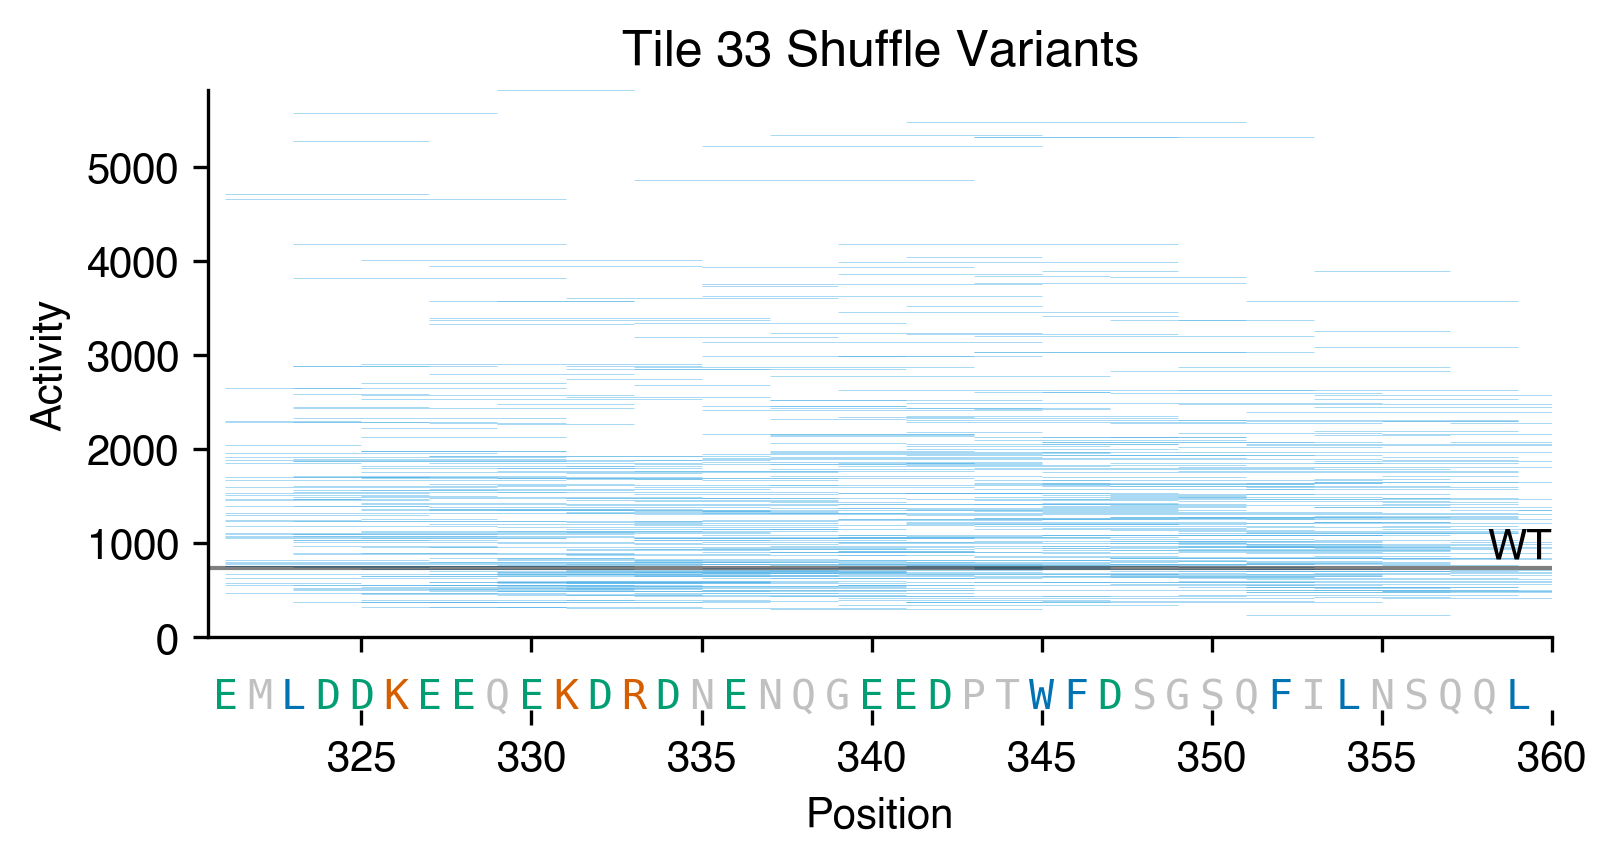

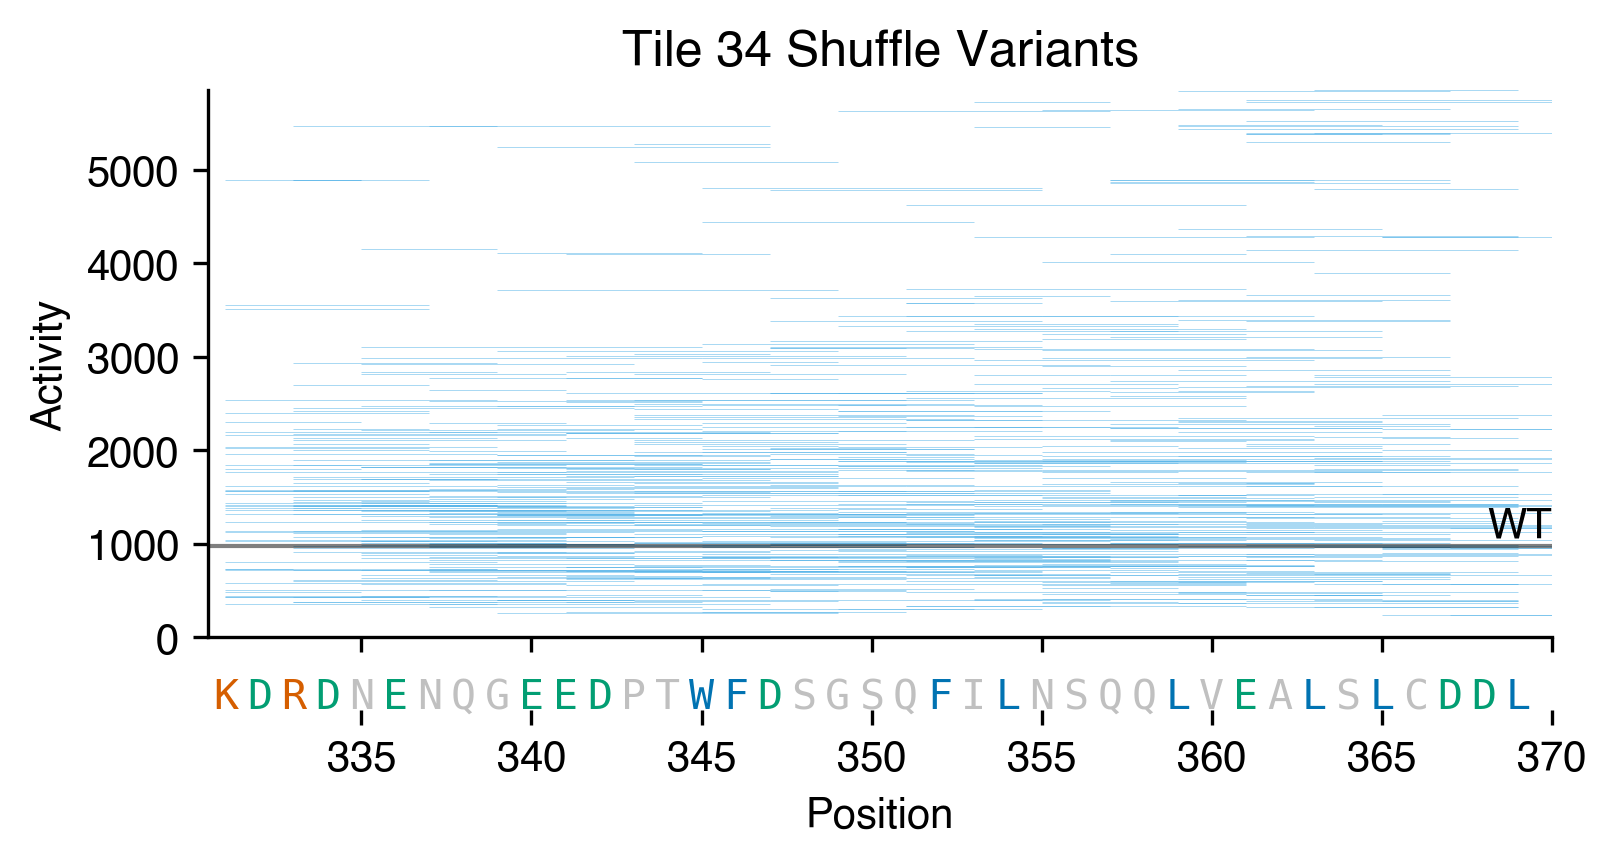

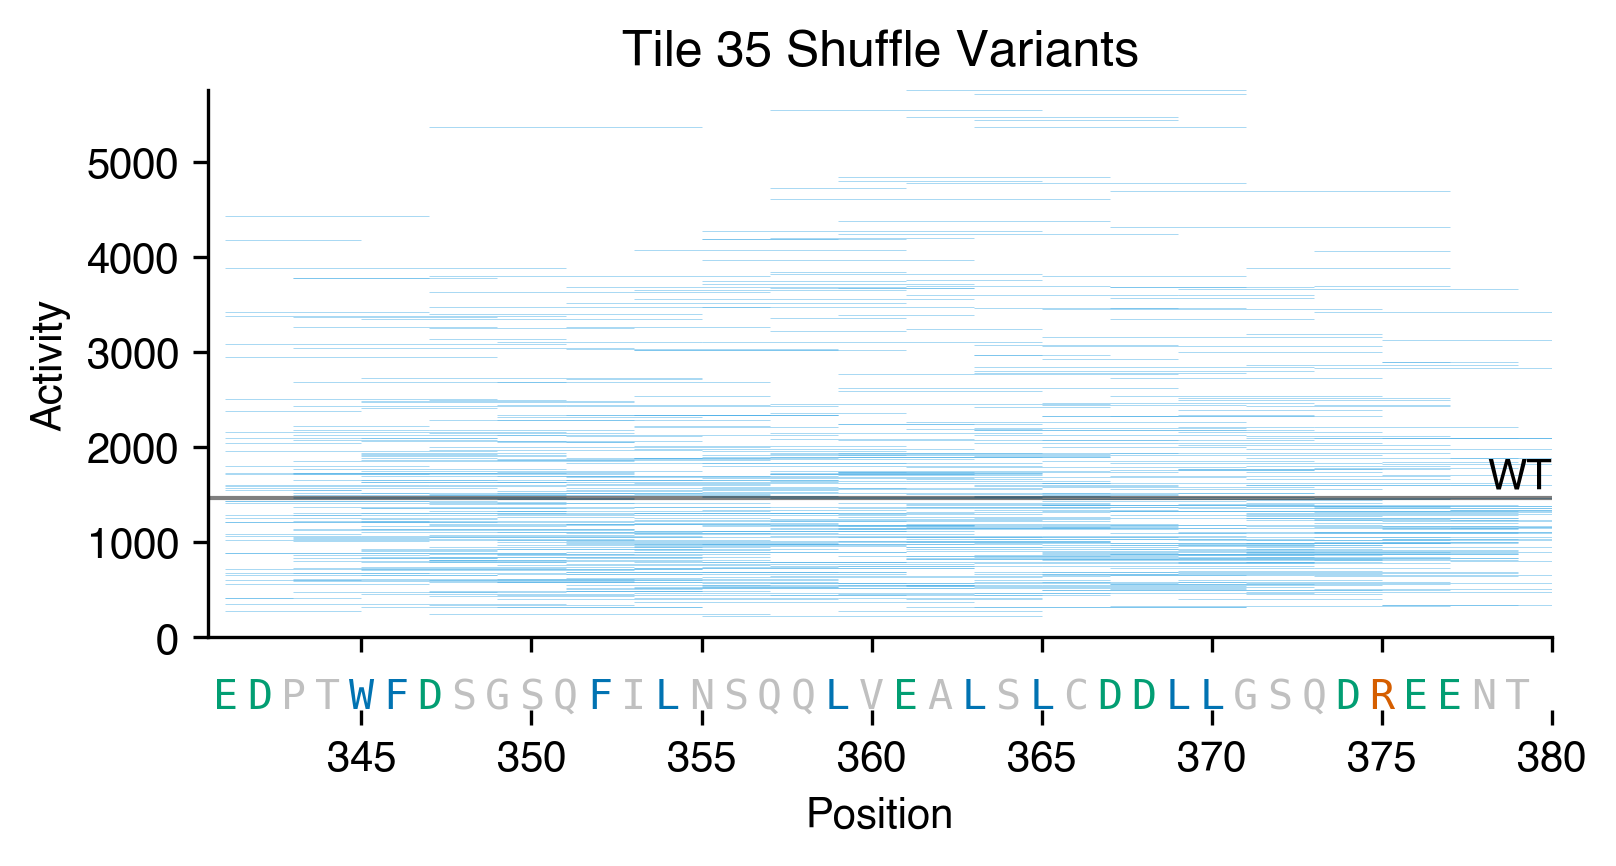

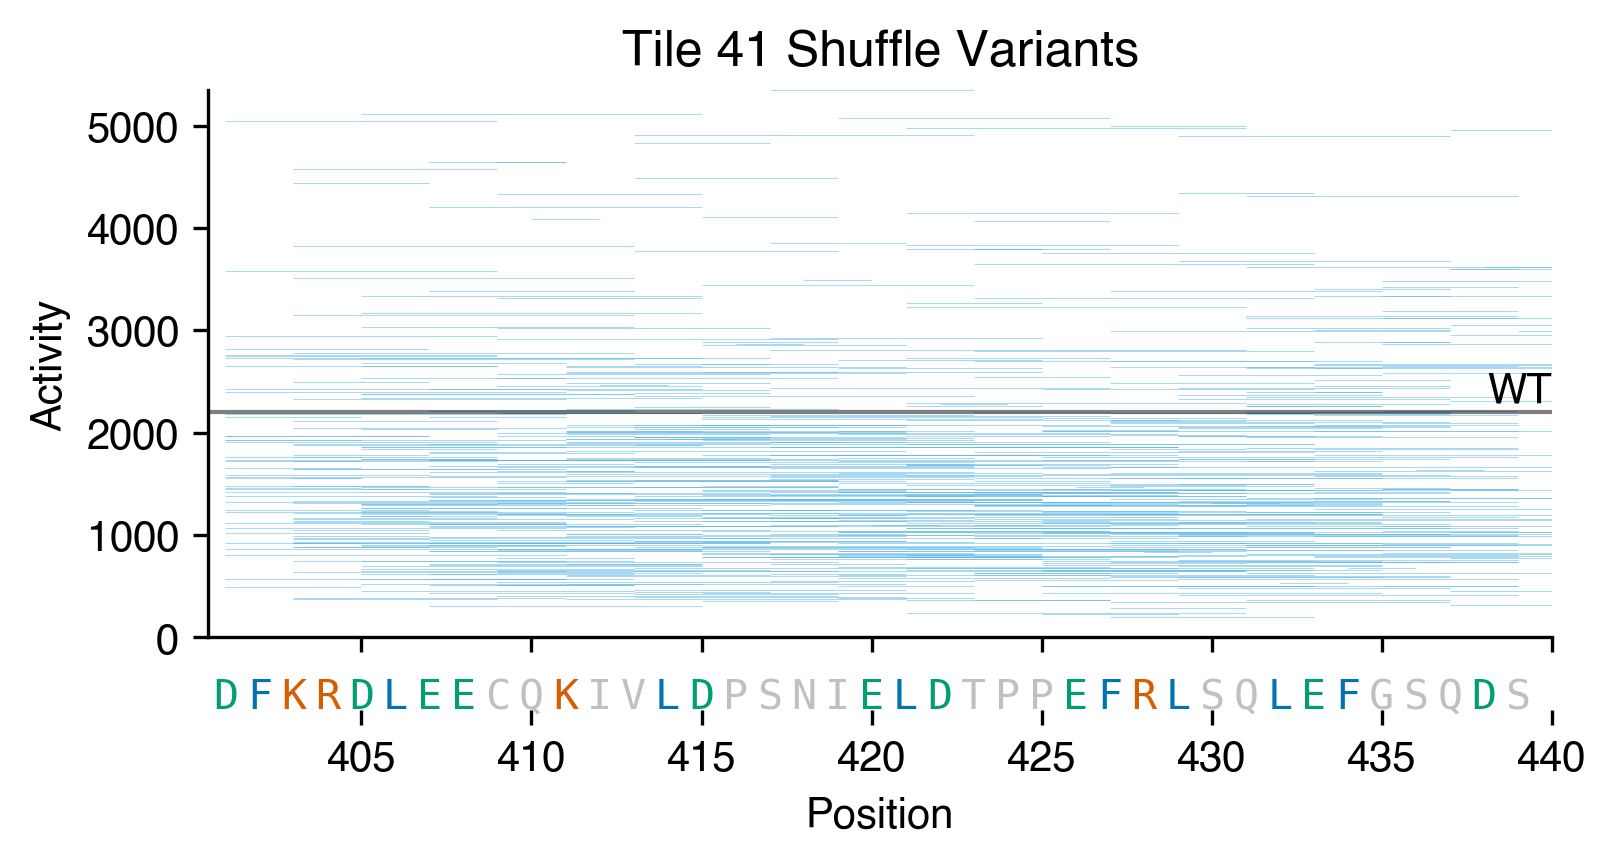

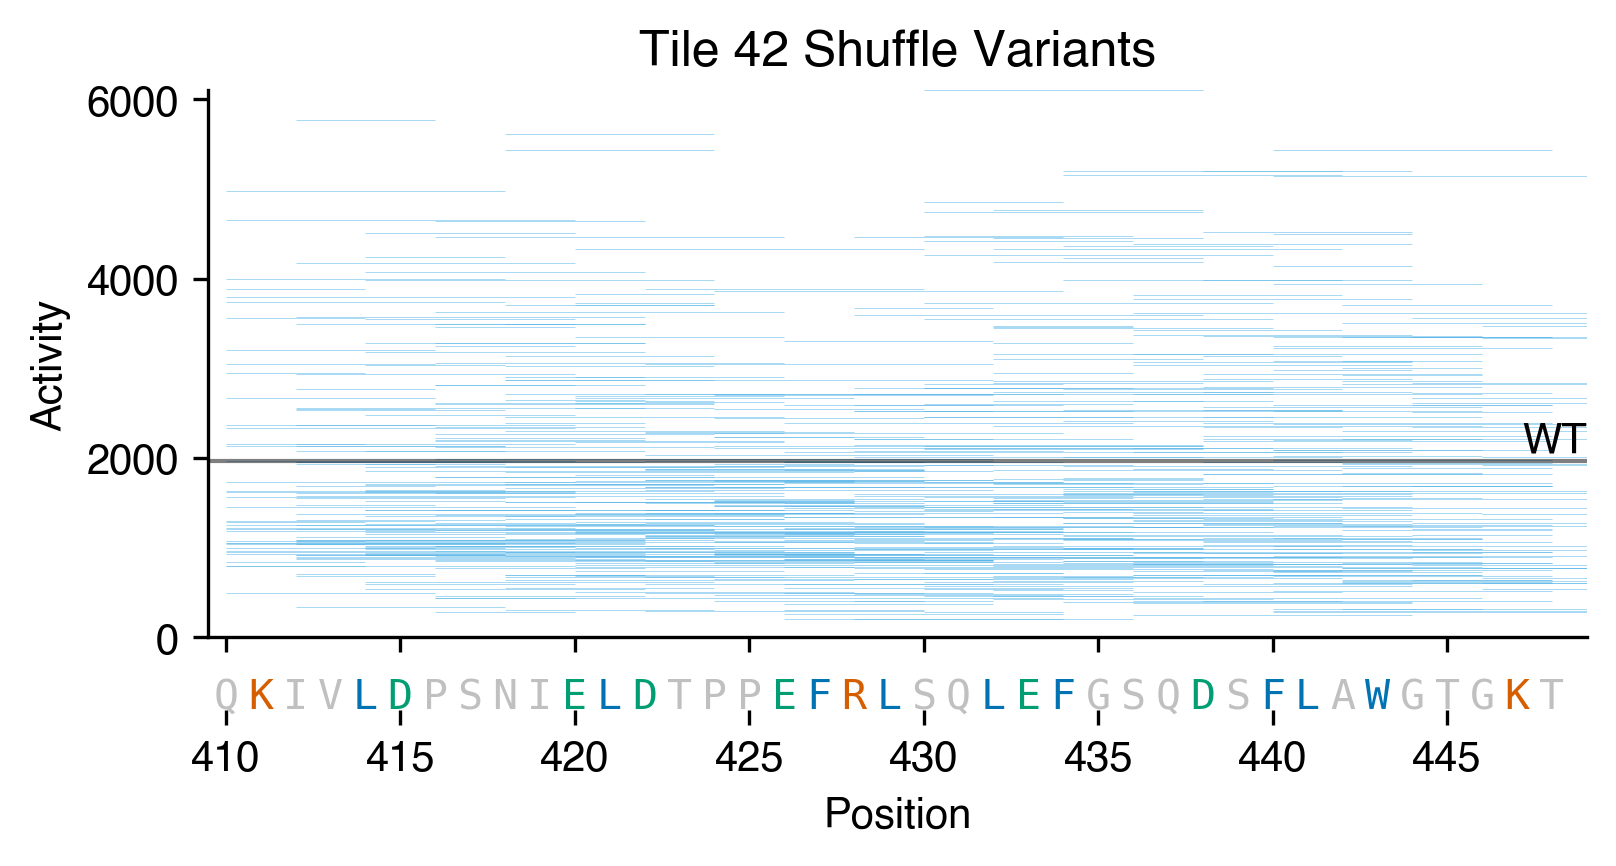

In [15]:
for tile in shuffle_vars_with_diff["tile"].unique():
#for tile in [33]:
    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile]
    plot_shuffles(df)
    plt.savefig("../output/figures/shuffles/" + str(tile))

In [16]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [17]:
df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 33]
df = df[df["shuffle_size"] == 4]
df

,Start,End,Description_var,Other_var,mid,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,...,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
52,321,360,33_shuffle_size4_ss2_pos0_1,shuffle_size4_ss2_pos0_1,341,DEMLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,BasicArTh.33,...,735.0852,895.351926,815.218563,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_1,321,325
53,321,360,33_shuffle_size4_ss2_pos0_2,shuffle_size4_ss2_pos0_2,341,MEDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1849.578475,1957.802238,1903.690356,BasicArTh.33,...,735.0852,895.351926,815.218563,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_2,321,325
54,321,360,33_shuffle_size4_ss2_pos0_3,shuffle_size4_ss2_pos0_3,341,LEDMDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,792.990838,773.845004,783.417921,BasicArTh.33,...,735.0852,895.351926,815.218563,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_3,321,325
55,321,360,33_shuffle_size4_ss2_pos0_4,shuffle_size4_ss2_pos0_4,341,MDLEDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1099.238875,1800.644636,1449.941756,BasicArTh.33,...,735.0852,895.351926,815.218563,"[321, 322, 324]","[E, M, D]",33,4,0_4,321,325
56,321,360,33_shuffle_size4_ss2_pos0_5,shuffle_size4_ss2_pos0_5,341,LDMEDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2047.458306,1847.524833,1947.491570,BasicArTh.33,...,735.0852,895.351926,815.218563,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_5,321,325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,321,360,33_shuffle_size4_ss2_pos18_6,shuffle_size4_ss2_pos18_6,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSLQVQ,717.995471,725.414811,721.705141,BasicArTh.33,...,735.0852,895.351926,815.218563,"[357, 359, 360]","[Q, L, V]",33,4,18_6,357,361
231,321,360,33_shuffle_size4_ss2_pos18_7,shuffle_size4_ss2_pos18_7,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQVL,1350.228989,1358.943439,1354.586214,BasicArTh.33,...,735.0852,895.351926,815.218563,"[359, 360]","[L, V]",33,4,18_7,357,361
232,321,360,33_shuffle_size4_ss2_pos18_8,shuffle_size4_ss2_pos18_8,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSLQQV,1814.183080,835.603467,1324.893274,BasicArTh.33,...,735.0852,895.351926,815.218563,"[357, 359]","[Q, L]",33,4,18_8,357,361
233,321,360,33_shuffle_size4_ss2_pos18_9,shuffle_size4_ss2_pos18_9,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQVQL,699.763392,601.923427,650.843409,BasicArTh.33,...,735.0852,895.351926,815.218563,"[358, 359, 360]","[Q, L, V]",33,4,18_9,357,361


In [18]:
# for shuffle_size in [2, 4, 6, 8, 10]:
#     df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 34]
#     df = df[df["shuffle_size"] == shuffle_size]
#     plot_shuffles(df)

##  Splitting up shuffles by state size

In [19]:
def plot_one_shuffle_track(tile, shuffle_size, ax1, shuffle_vars_with_diff = shuffle_vars_with_diff, alpha = 1, lw = 1):
    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile]
    if shuffle_size:
        df = df[df["shuffle_size"] == shuffle_size]
    if len(df) > 0:
        
        max_y = 0
        for i in range(len(df)):
            row_vars = df["vars"].iloc[i]
            ax1.hlines(y=df[activity_col + "_var"].iloc[i], 
                       xmin=df["pos_start"].iloc[i], 
                       xmax=df["pos_end"].iloc[i], 
                       color=sns.color_palette('colorblind')[-1], 
                       linestyle='-', alpha = alpha, lw = lw)
            max_y = max(max_y, df[activity_col + "_var"].iloc[i])
            
    
                               
        ax1.axhline(df[activity_col + "_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
        ax1.set_xlim(df["Start"].iloc[i] - 0.5, df["End"].iloc[i])    
        ax1.set_ylim(0, max_y)
        if shuffle_size == 2:
            ax1.text(x = df["End"].iloc[i], y = df[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    sns.despine(ax = ax1, left = False)
        #ax2.set_yticklabels([])
    if shuffle_size:
        ax1.set_ylabel(str(shuffle_size) + "AA", rotation = 0, va = 'center')
    else:
        ax1.set_ylabel("All", rotation = 0, va = 'center')

def plot_AA_track(start, end, ax2):
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(start, end):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
    sns.despine(ax = ax2, left = True, bottom = True)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax2.set_xlabel("Position")


def plot_marg_hist(tile_df, ax):
    sns.histplot(data = tile_df, y = "Activity_S3_1_var", ax = ax, edgecolor = 'white', color = sns.color_palette('colorblind')[-1], stat = 'density', bins = 15)
    sns.despine(ax = ax)

In [22]:
shuffle_vars_with_diff.columns

Index(['Start', 'End', 'Description_var', 'Other_var', 'mid', 'tile_var',
       'Activity_S3_1_var', 'Activity_S3_2_var', 'lib2_avg_var',
       'Description_wt', 'Other_wt', 'tile_wt', 'Activity_S3_1_wt',
       'Activity_S3_2_wt', 'lib2_avg_wt', 'vars', 'AAs', 'tile',
       'shuffle_size', 'coordinates', 'pos_start', 'pos_end'],
      dtype='object')

In [26]:
shuffle_vars_with_diff_for_JD = shuffle_vars_with_diff[["Start", "End", "Description_var", "tile_var", "Activity_S3_1_var", "Activity_S3_2_var", "tile_wt", "Activity_S3_1_wt", "Activity_S3_2_wt"]]
shuffle_vars_with_diff_for_JD

,Start,End,Description_var,tile_var,Activity_S3_1_var,Activity_S3_2_var,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt
0,321,360,33_shuffle_size2_ss2_pos0_1,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,763.760346,695.590132,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926
1,321,360,33_shuffle_size2_ss2_pos1_1,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1473.675797,1687.523804,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926
2,321,360,33_shuffle_size2_ss2_pos2_1,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1706.977440,1719.464603,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926
3,321,360,33_shuffle_size2_ss2_pos4_1,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,325.349781,627.000002,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926
4,321,360,33_shuffle_size2_ss2_pos5_1,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,677.584266,878.104555,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,735.085200,895.351926
...,...,...,...,...,...,...,...,...,...
3568,410,449,42_shuffle_size10_ss2_pos15_6,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,908.291934,601.458747,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378
3569,410,449,42_shuffle_size10_ss2_pos15_7,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3620.400685,3866.897601,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378
3570,410,449,42_shuffle_size10_ss2_pos15_8,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,1014.433117,629.787497,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378
3571,410,449,42_shuffle_size10_ss2_pos15_9,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,2375.766170,1866.065374,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,1962.781522,1933.058378


In [20]:
shuffle_vars_with_diff.to_csv("../data/all_shuffle_vars.csv")

In [27]:
shuffle_vars_with_diff_for_JD.to_csv("../data/all_shuffle_vars_JD.csv")

In [245]:
def plot_size_sep_shuffles(tile_num):
    fig, axs = plt.subplots(7, 2, figsize = (5,6), dpi = 300, sharex = 'col', sharey = 'row', gridspec_kw={'height_ratios': [1, 1, 1, 1, 1, 1, 0.2], 'width_ratios' : [1, 0.2]})

    i = 0
    for ss in [2, 4, 6, 8, 10]:
        plot_one_shuffle_track(tile_num, ss, axs[i][0], shuffle_vars_with_diff, alpha = 0.25, lw = 0.6)

        df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile_num]
        df = df[df["shuffle_size"] == ss]
        #display(df)
        plot_marg_hist(df, axs[i][1])
        if len(df) > 0:
            axs[i][1].axhline(df["Activity_S3_1_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
        i += 1

    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile_num]
    plot_one_shuffle_track(tile_num, False, axs[-2][0], shuffle_vars_with_diff, alpha = 0.25, lw = 0.6)
    plot_marg_hist(df, axs[-2][1])
    axs[-2][1].axhline(df["Activity_S3_1_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
   
    plot_AA_track(df["Start"].iloc[0], df["End"].iloc[1], axs[-1][0])
    #plot_marg_hist(pd.DataFrame(), axs[-1][0])
    #sns.despine(ax = axs[-1][0], left = True)

        
    axs[0][1].set_visible(False)
    axs[-1][1].set_visible(False)
    
    print(axs[-1][1].get_xticks())

    axs[-2][1].tick_params(axis='x', labelbottom=True) 
    labels = [item.get_text() for item in axs[-2][1].get_xticklabels()]
    axs[-2][1].set_xticklabels([str(round(float(label), 4)) for label in labels])

    #sns.despine(ax = axs[-1][1], left = True, bottom = True)
    
    fig.tight_layout(pad = 0)
    fig.supylabel("Activity, Shuffle Size", x = -0.04)
    fig.suptitle("Tile " + str(tile_num) + " Shuffles", y = 1.02, x = 0.57)
    plt.savefig("../output/figures/shuffle_size_split/" + str(tile_num) + ".png")

In [246]:
# ! mkdir ../output/figures/shuffle_size_split

In [247]:
# fig, axs = plt.subplots(1, 2, sharey = True, sharex = 'col')
# plot_one_shuffle_track(34, False, axs[0], shuffle_vars_with_diff = shuffle_vars_with_diff, alpha = 0.5, lw = 0.5)
# plot_marg_hist(shuffle_vars_with_diff, axs[1])

# sns.despine(ax = axs[1])
# plt.tight_layout(pad = 0)

[0.    0.001 0.002]


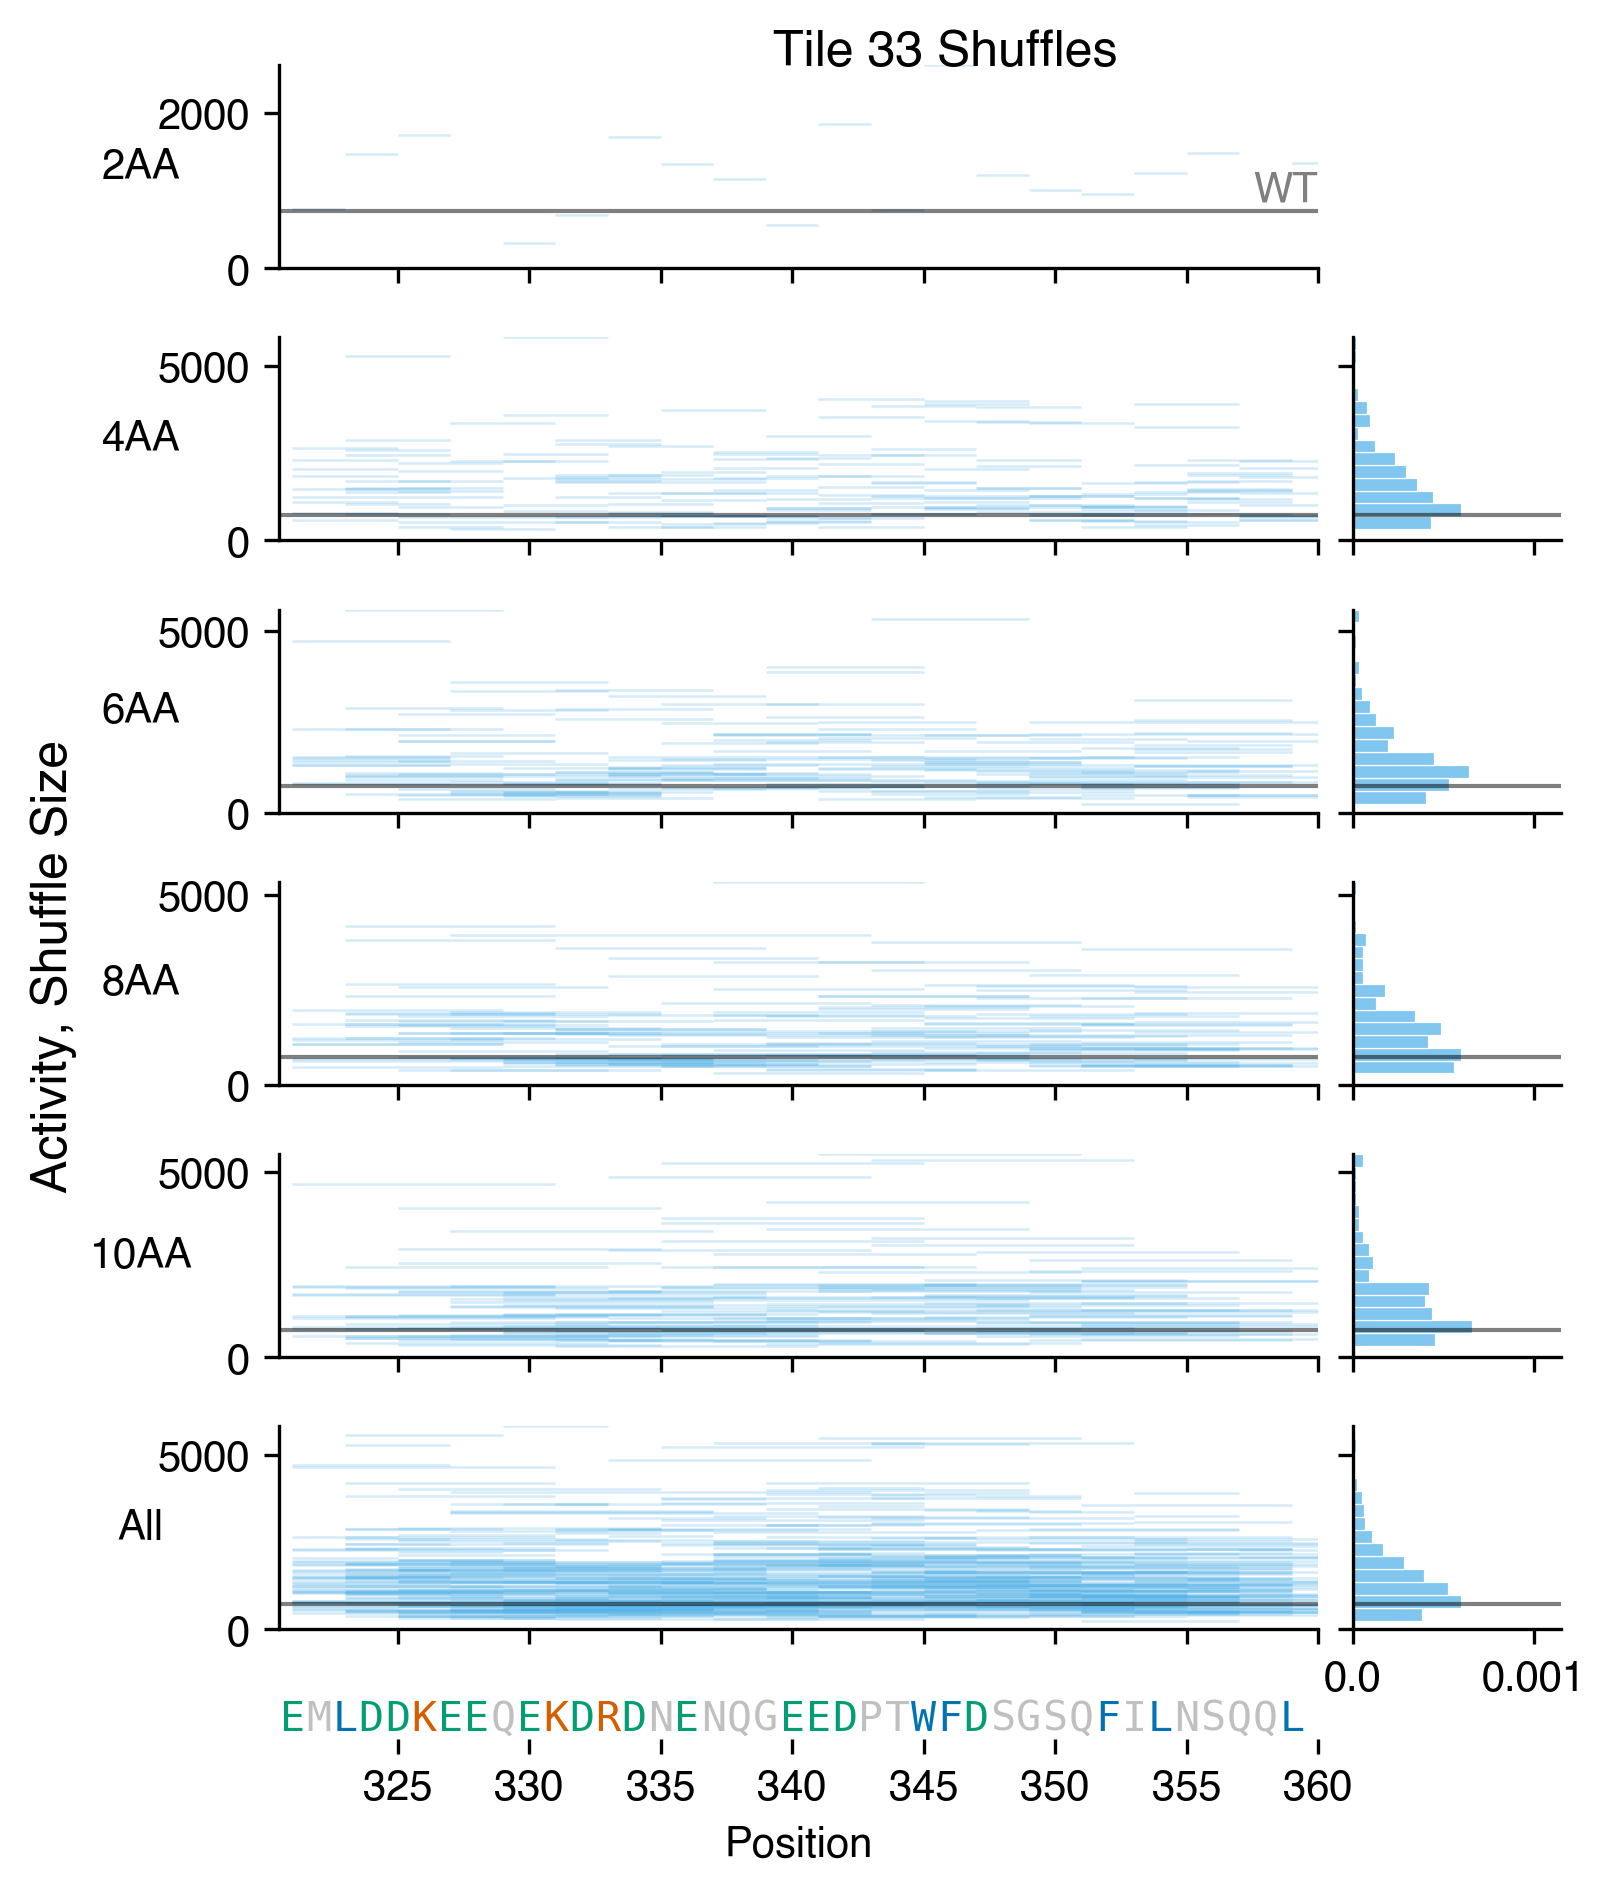

In [248]:
plot_size_sep_shuffles(33)

33
[0.    0.001 0.002]
34
[0.    0.001 0.002]
35
[0.     0.0005 0.001 ]
41
[0.     0.0005 0.001 ]
42
[0.     0.0005 0.001 ]


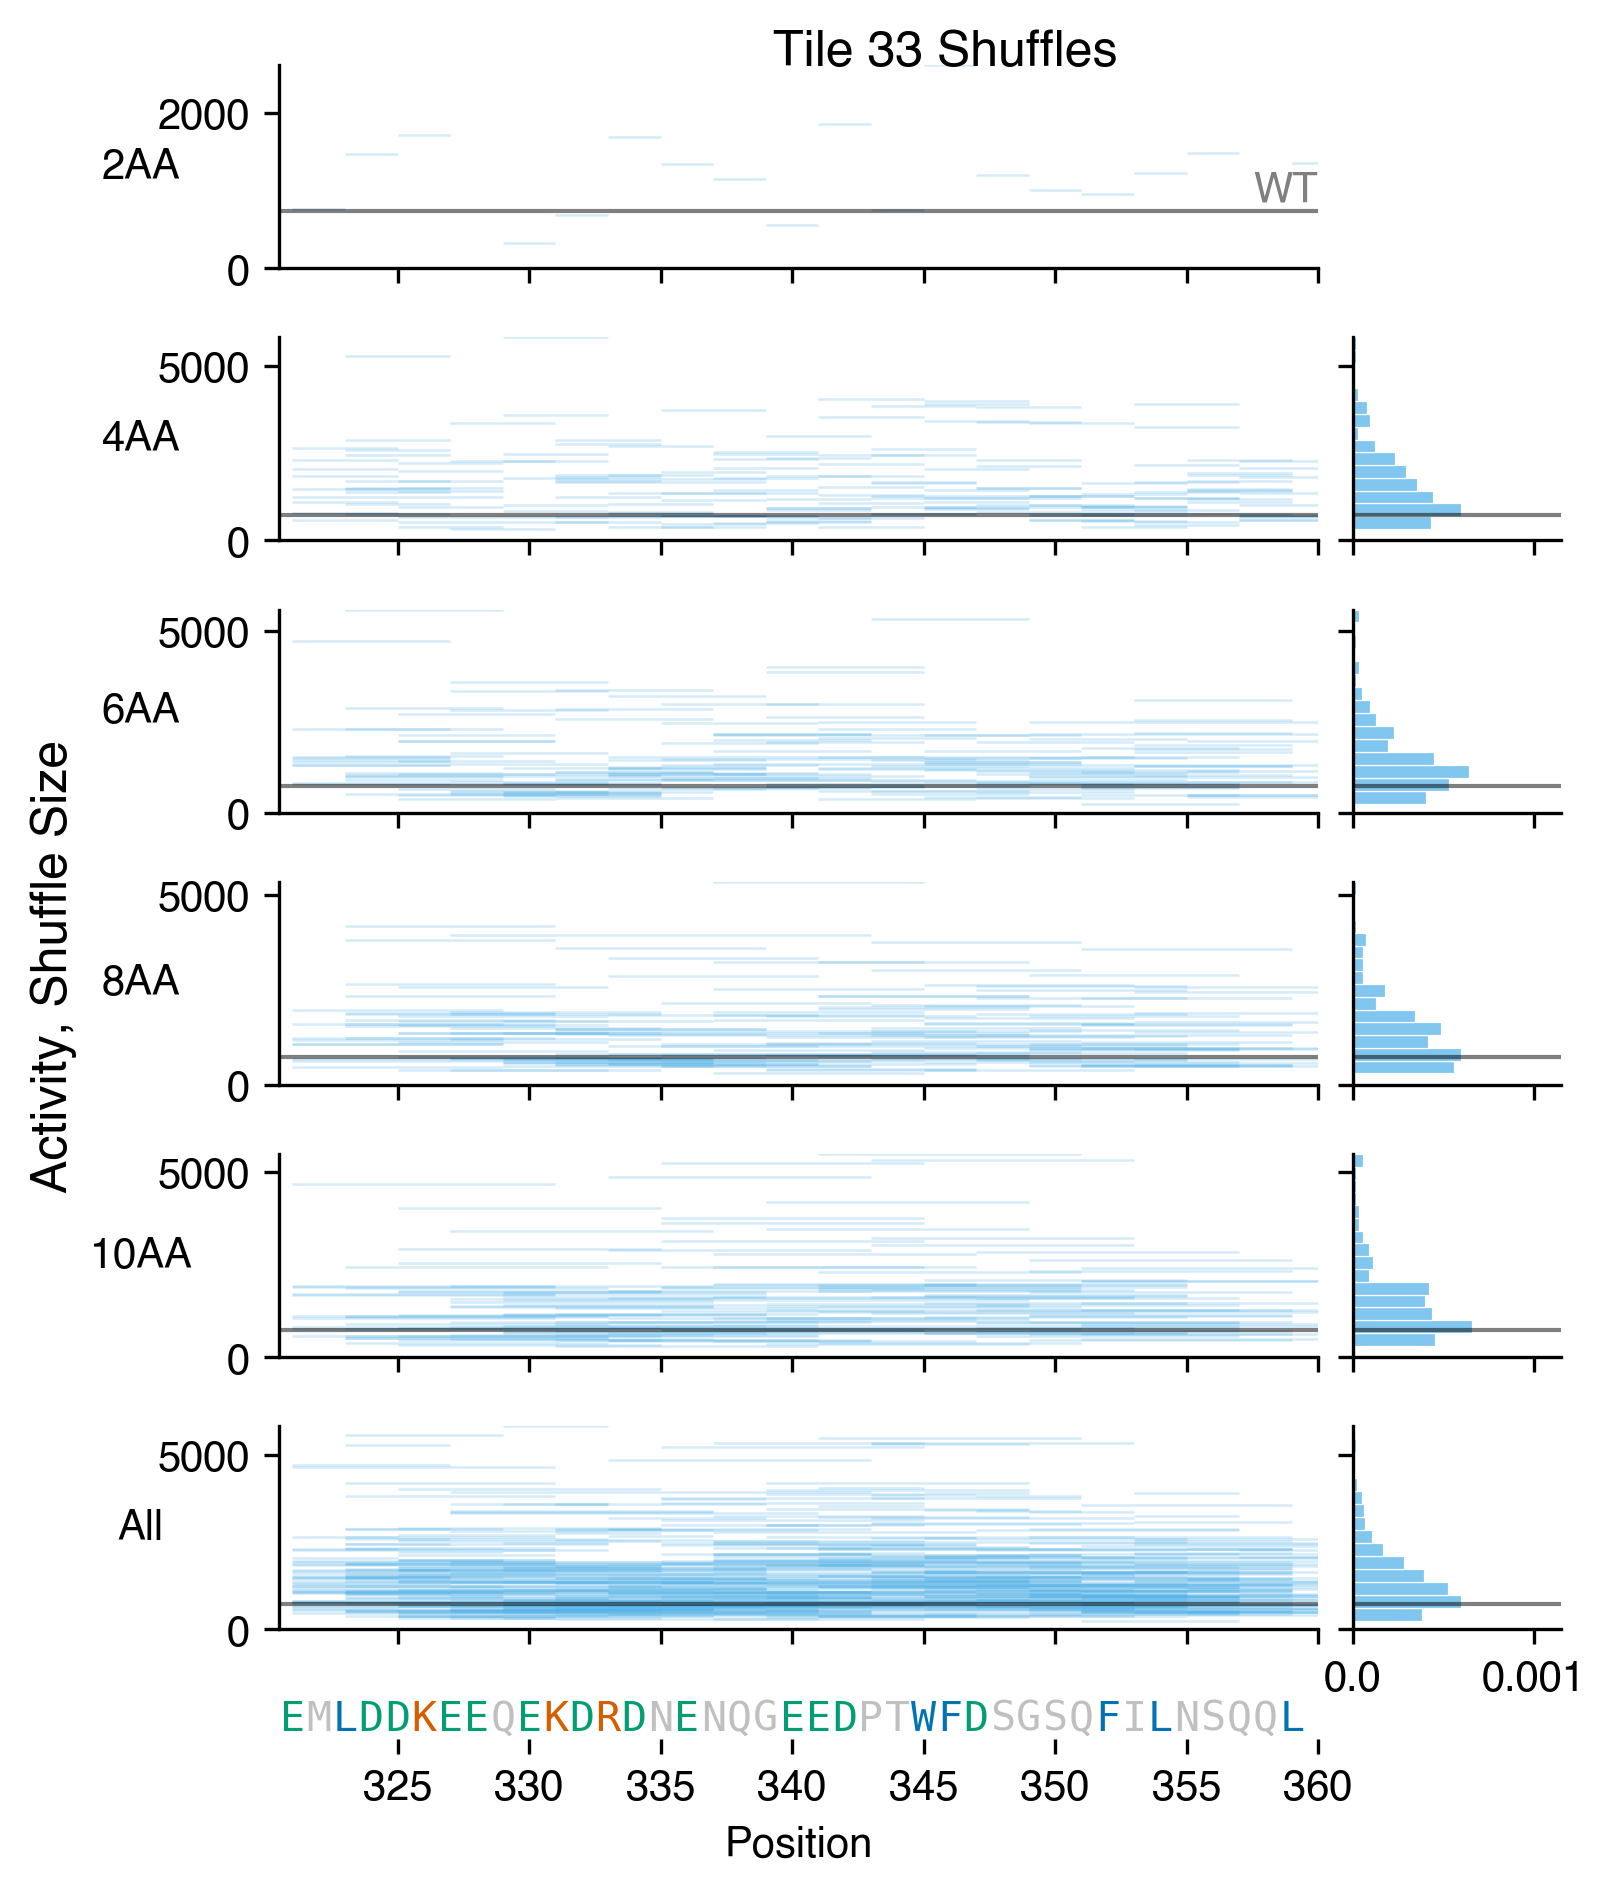

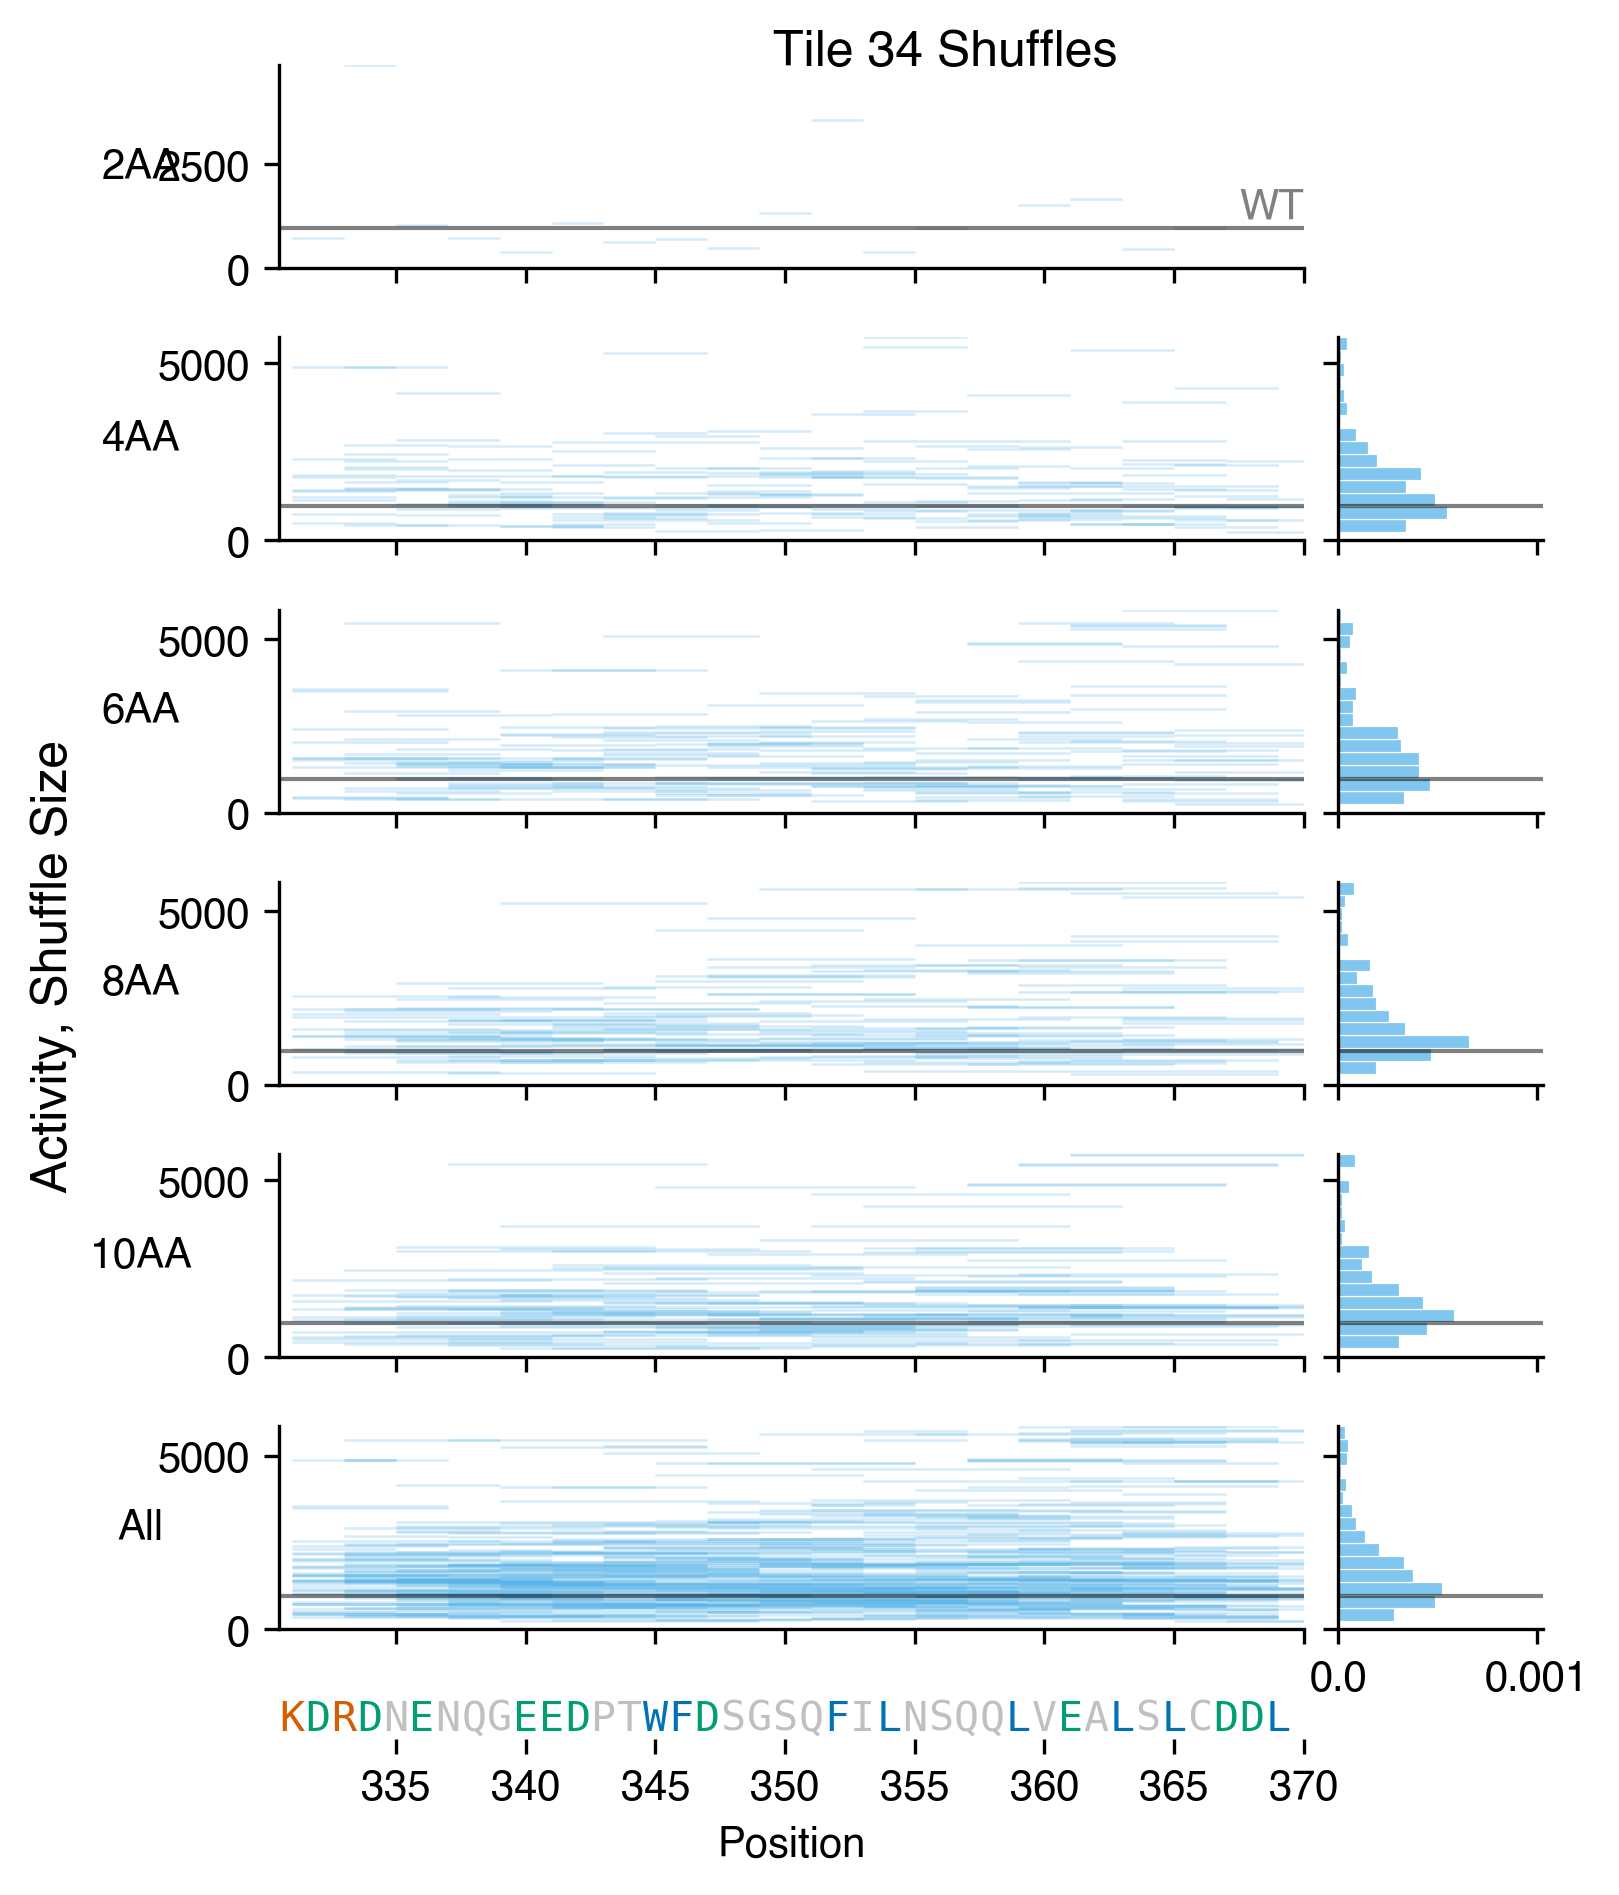

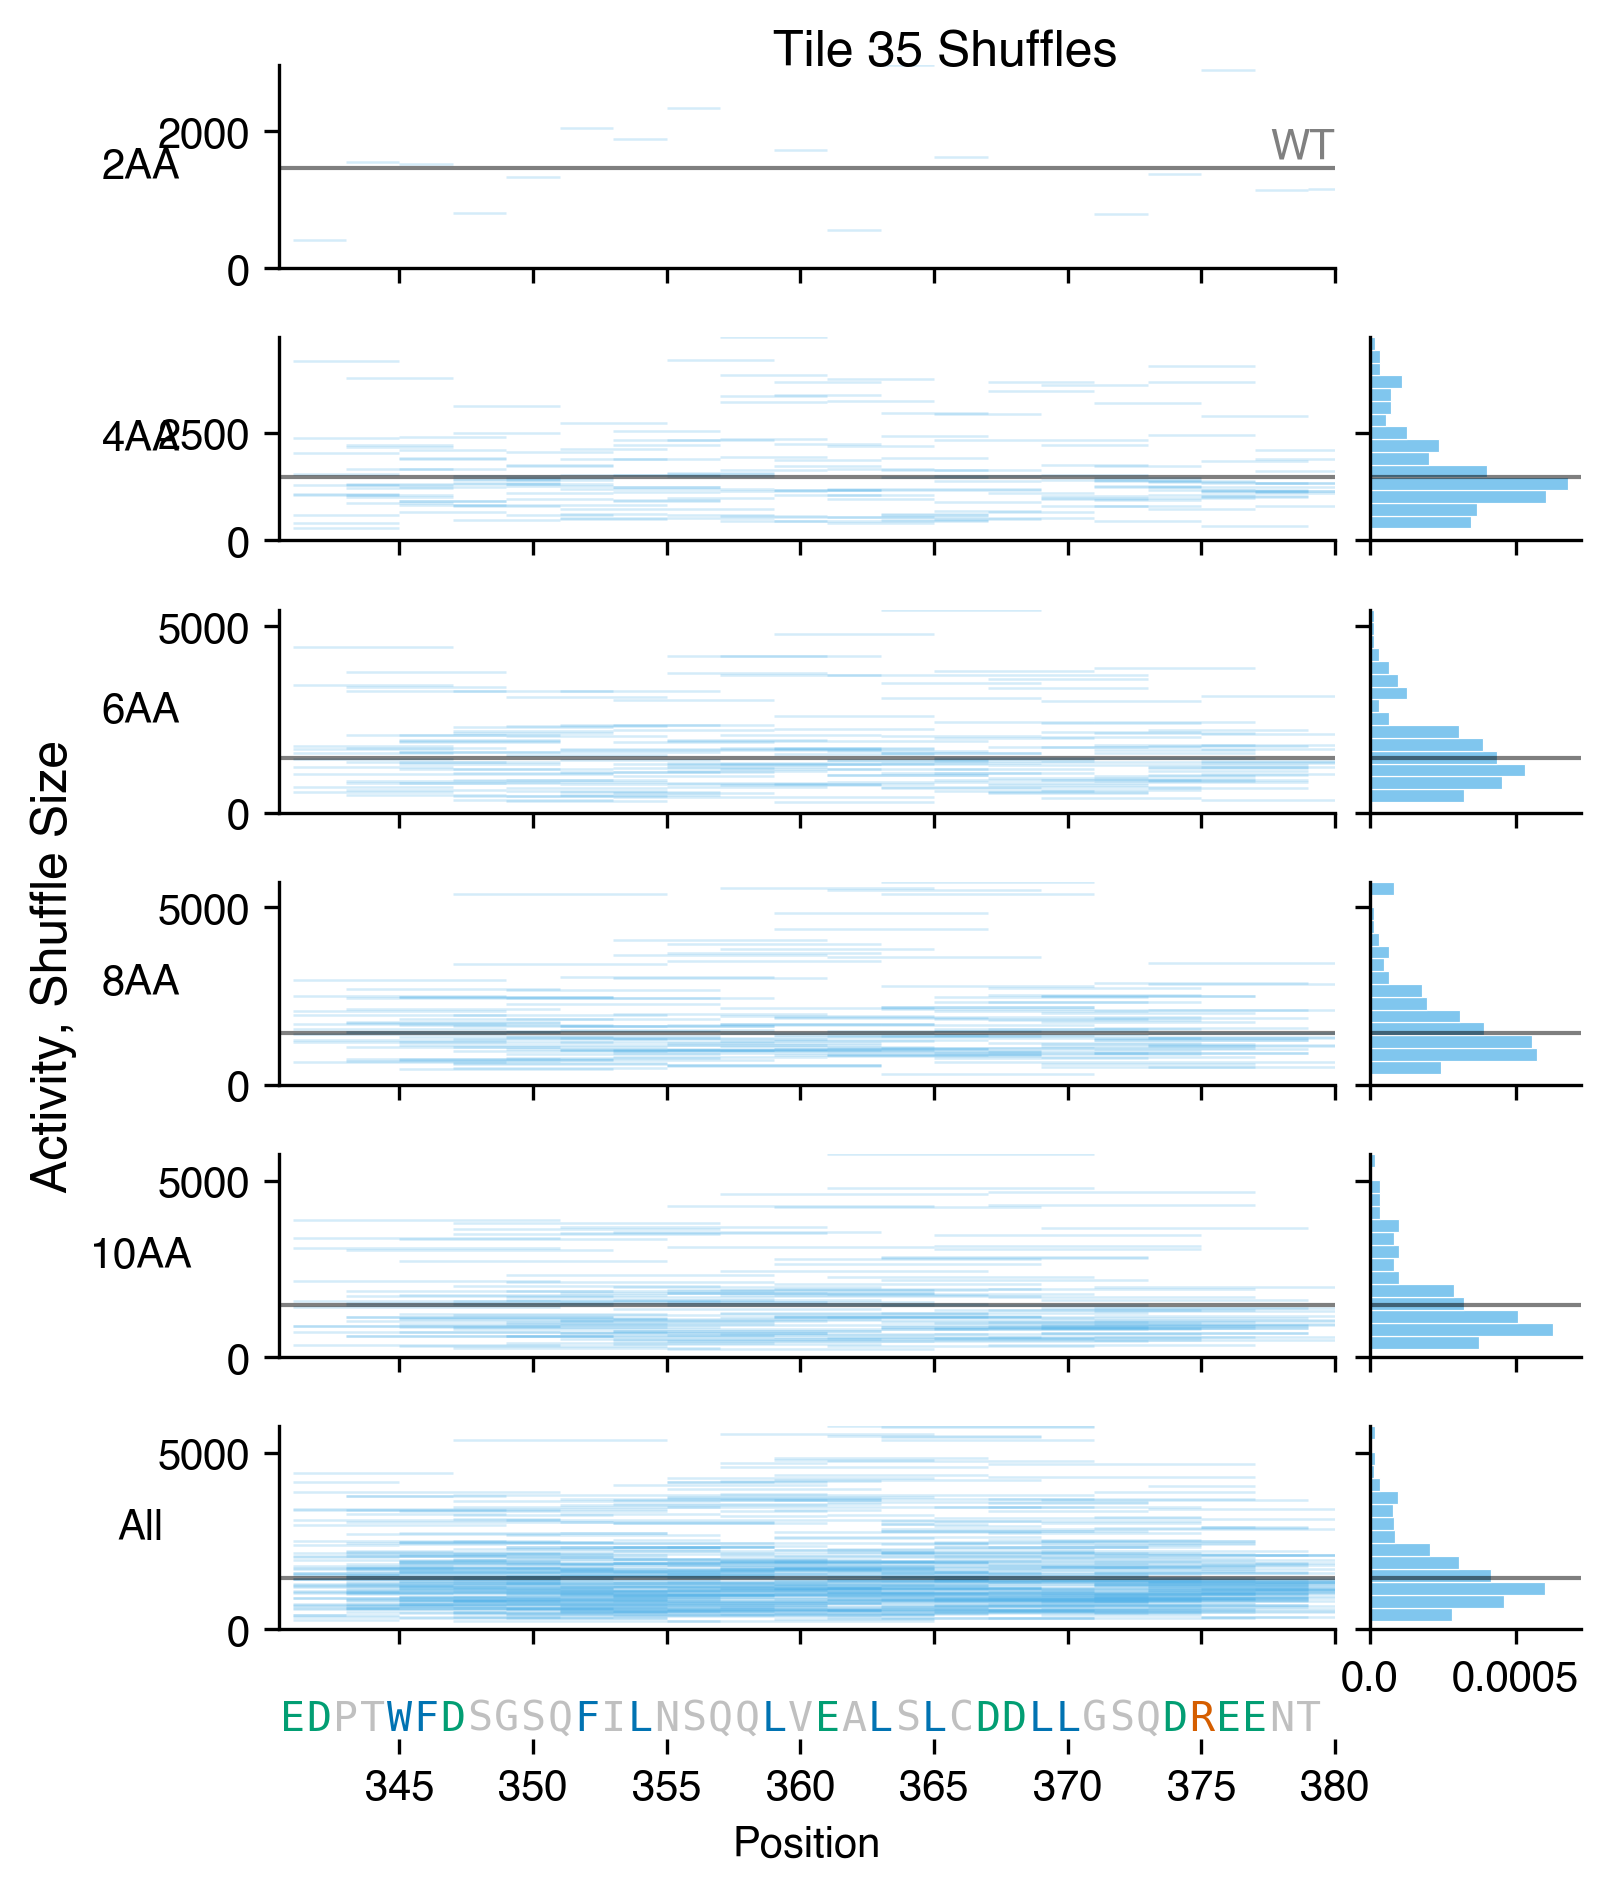

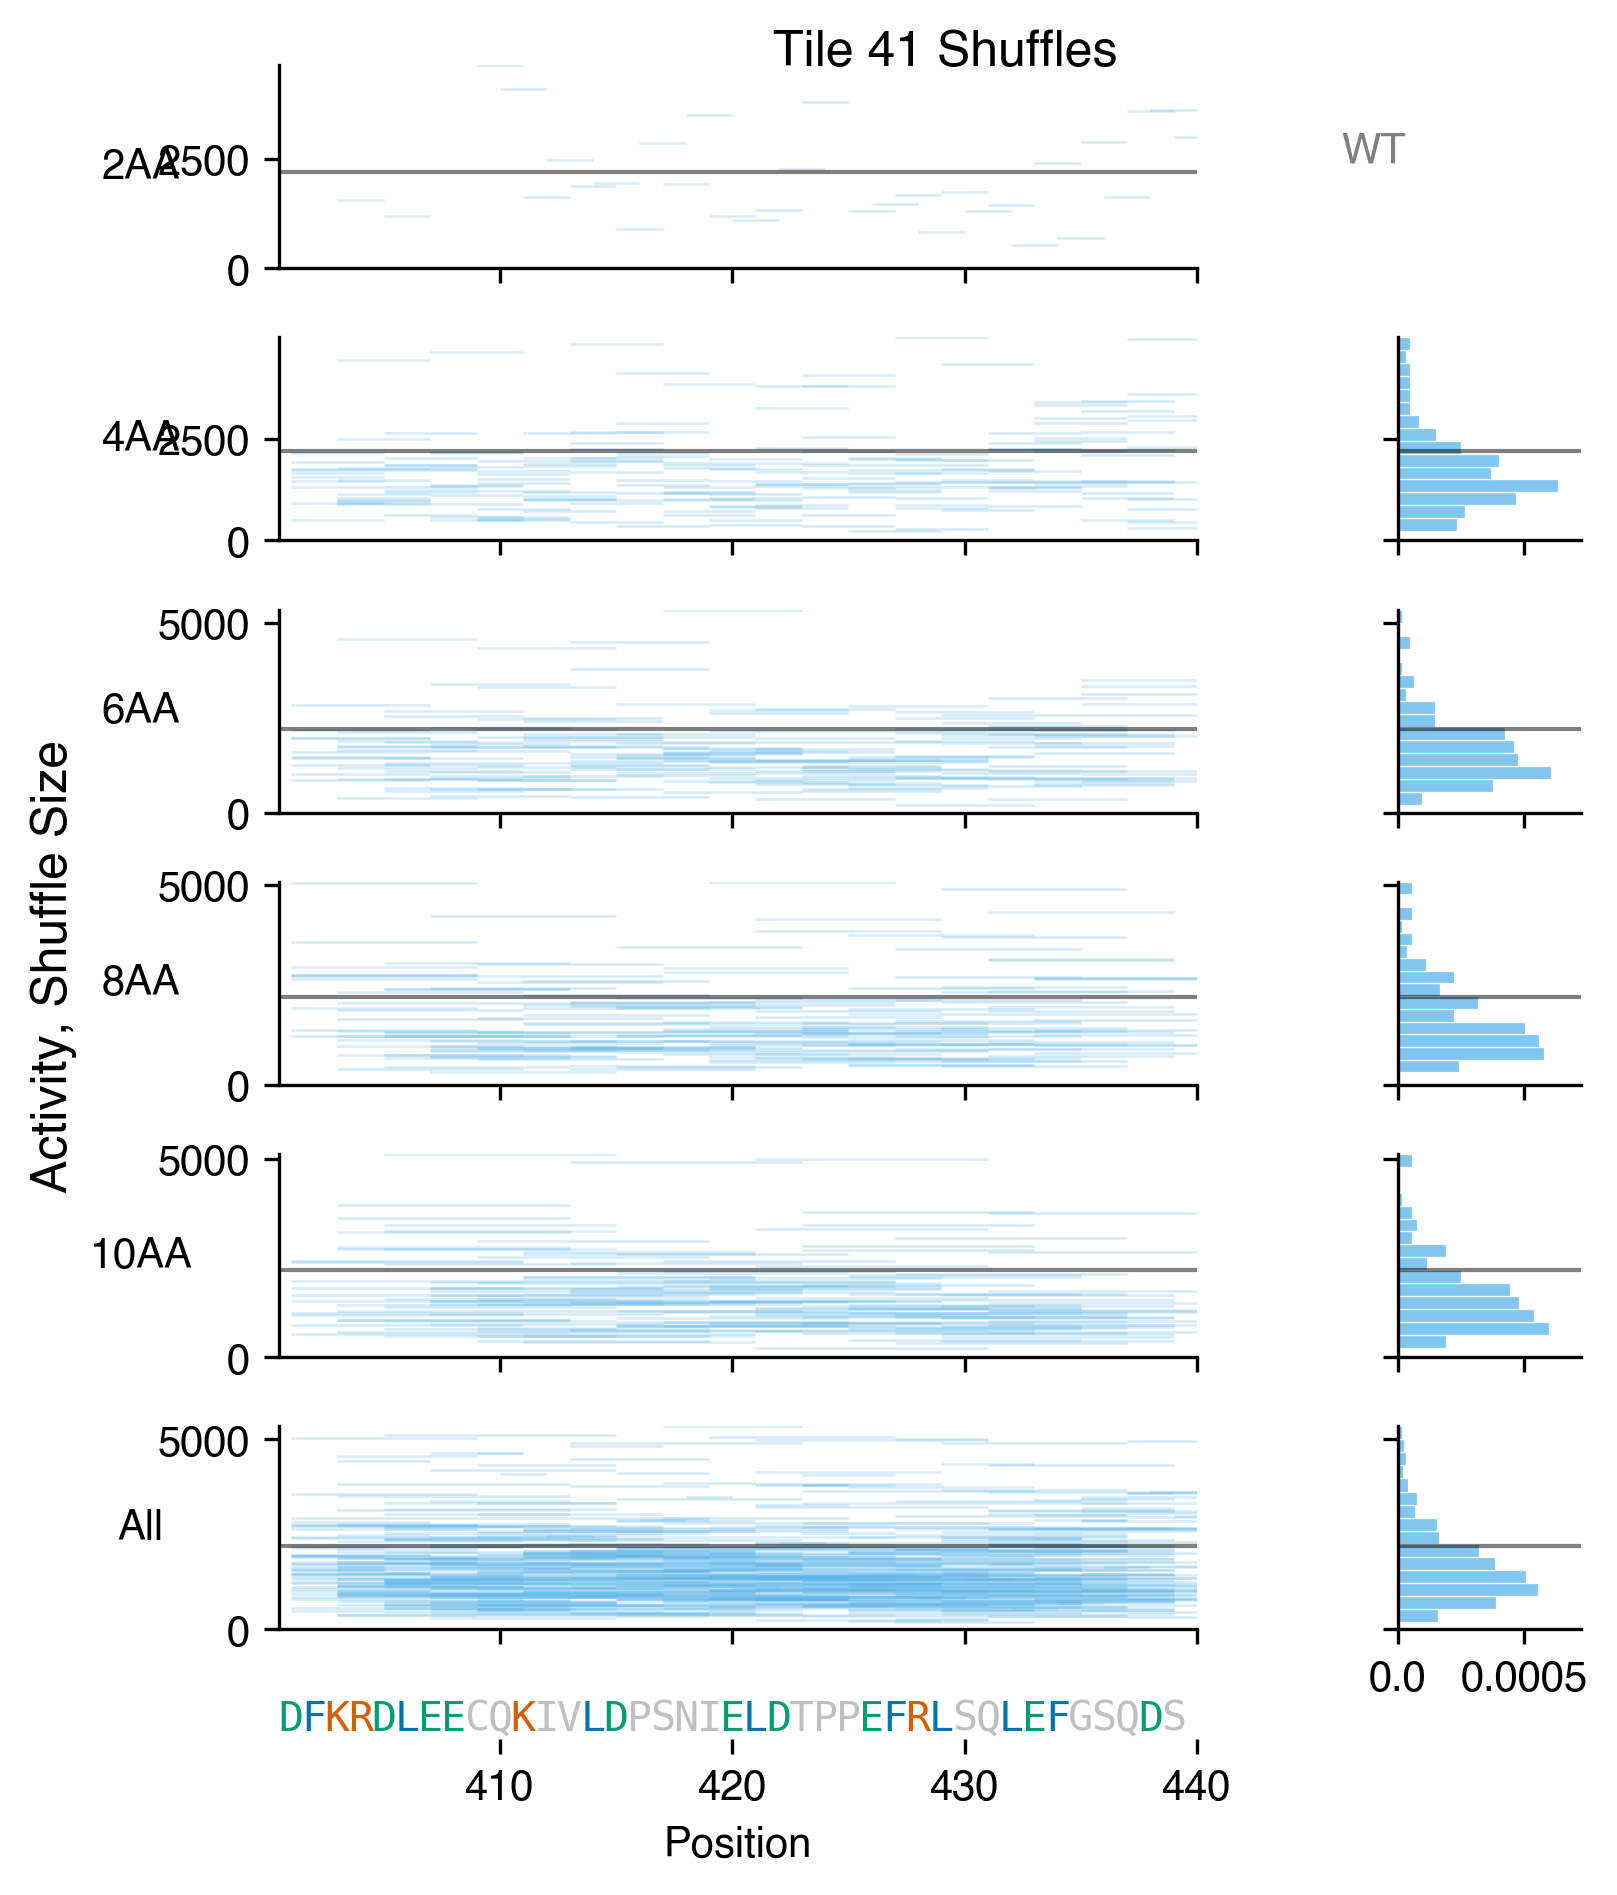

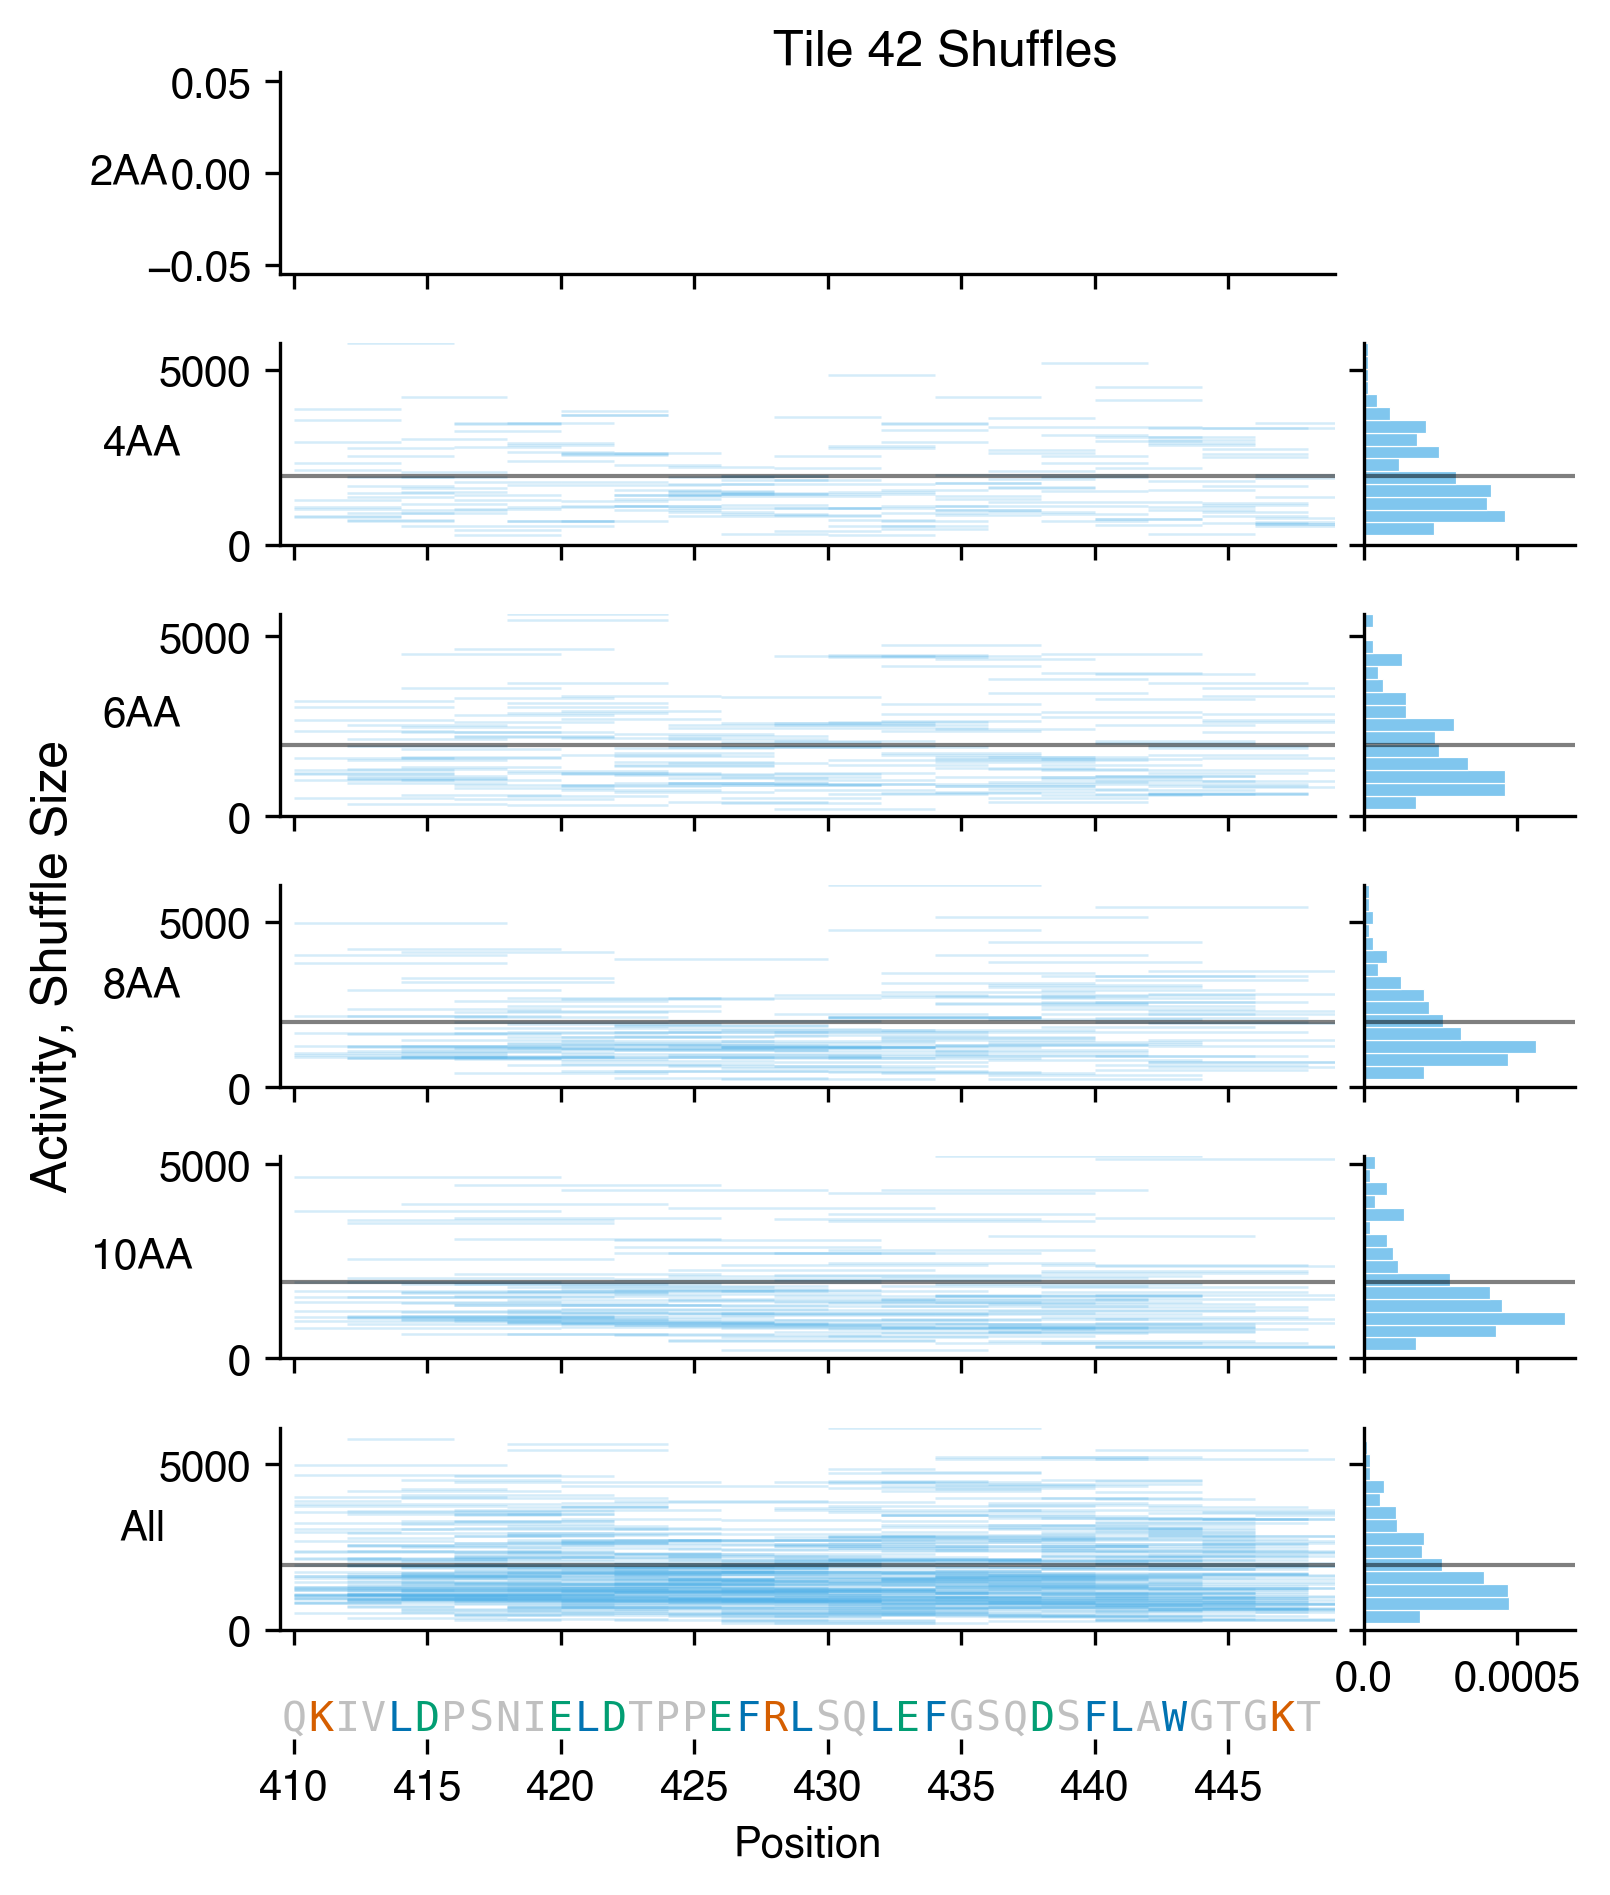

In [249]:
for tile in shuffle_vars_with_diff["tile"].unique():
    print(tile) 
    plot_size_sep_shuffles(tile)
    

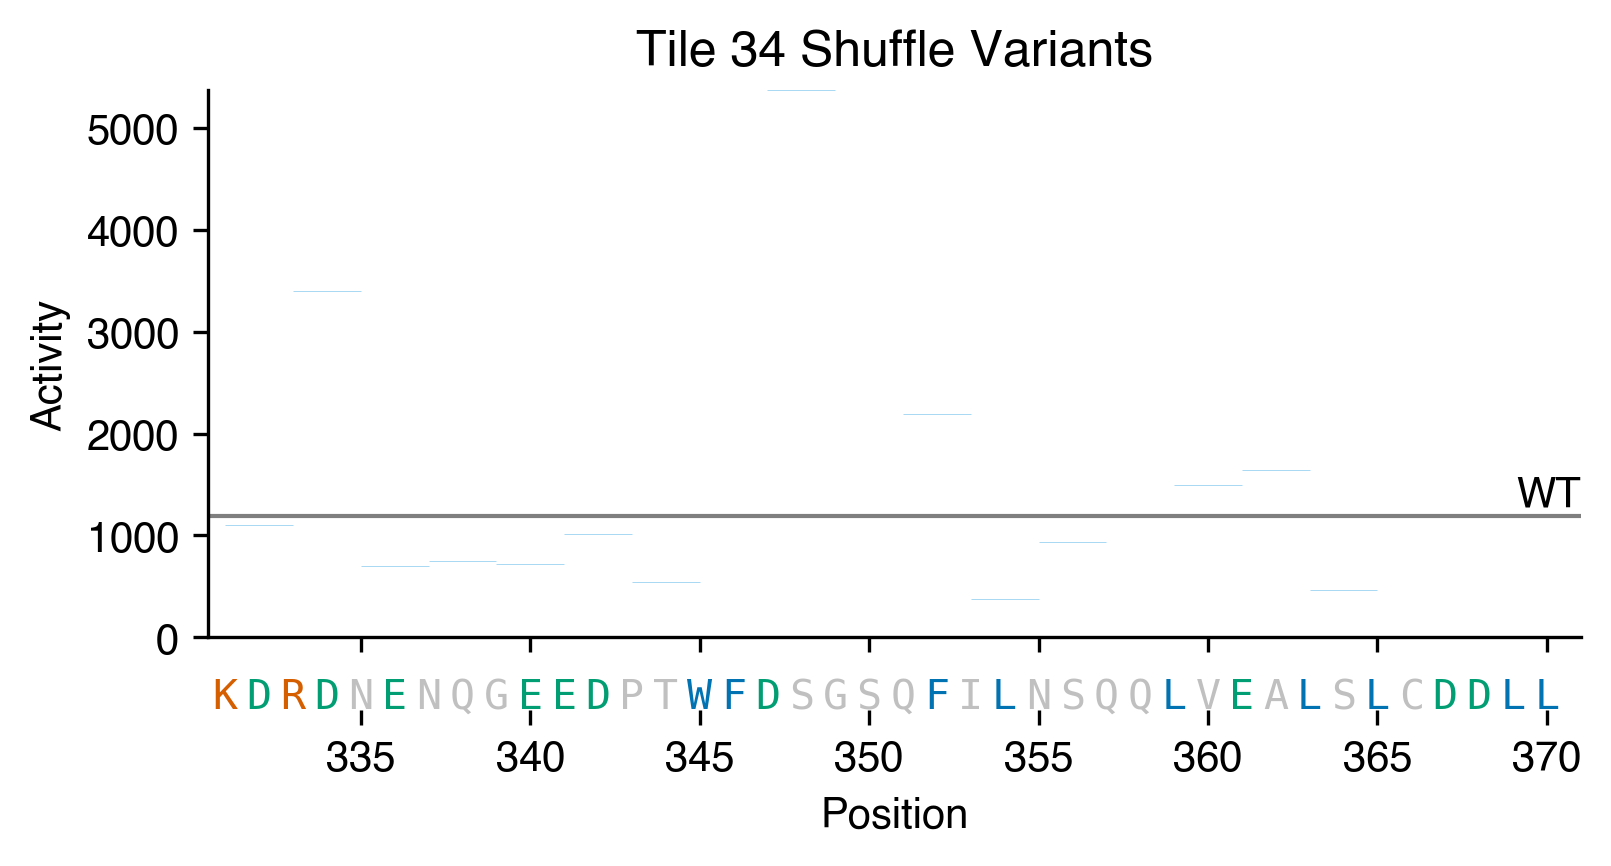

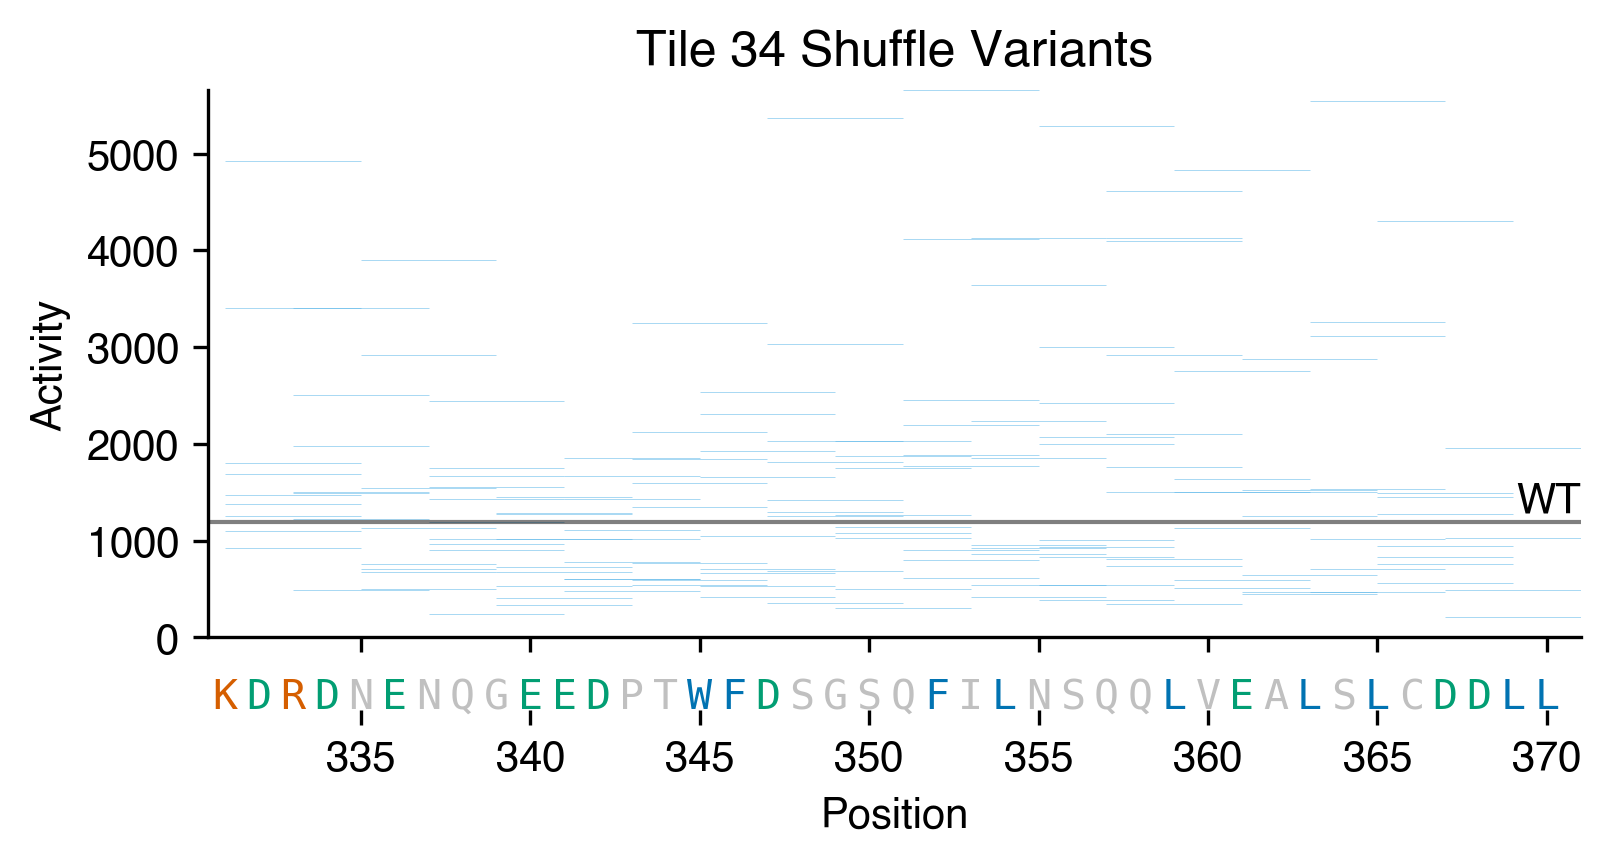

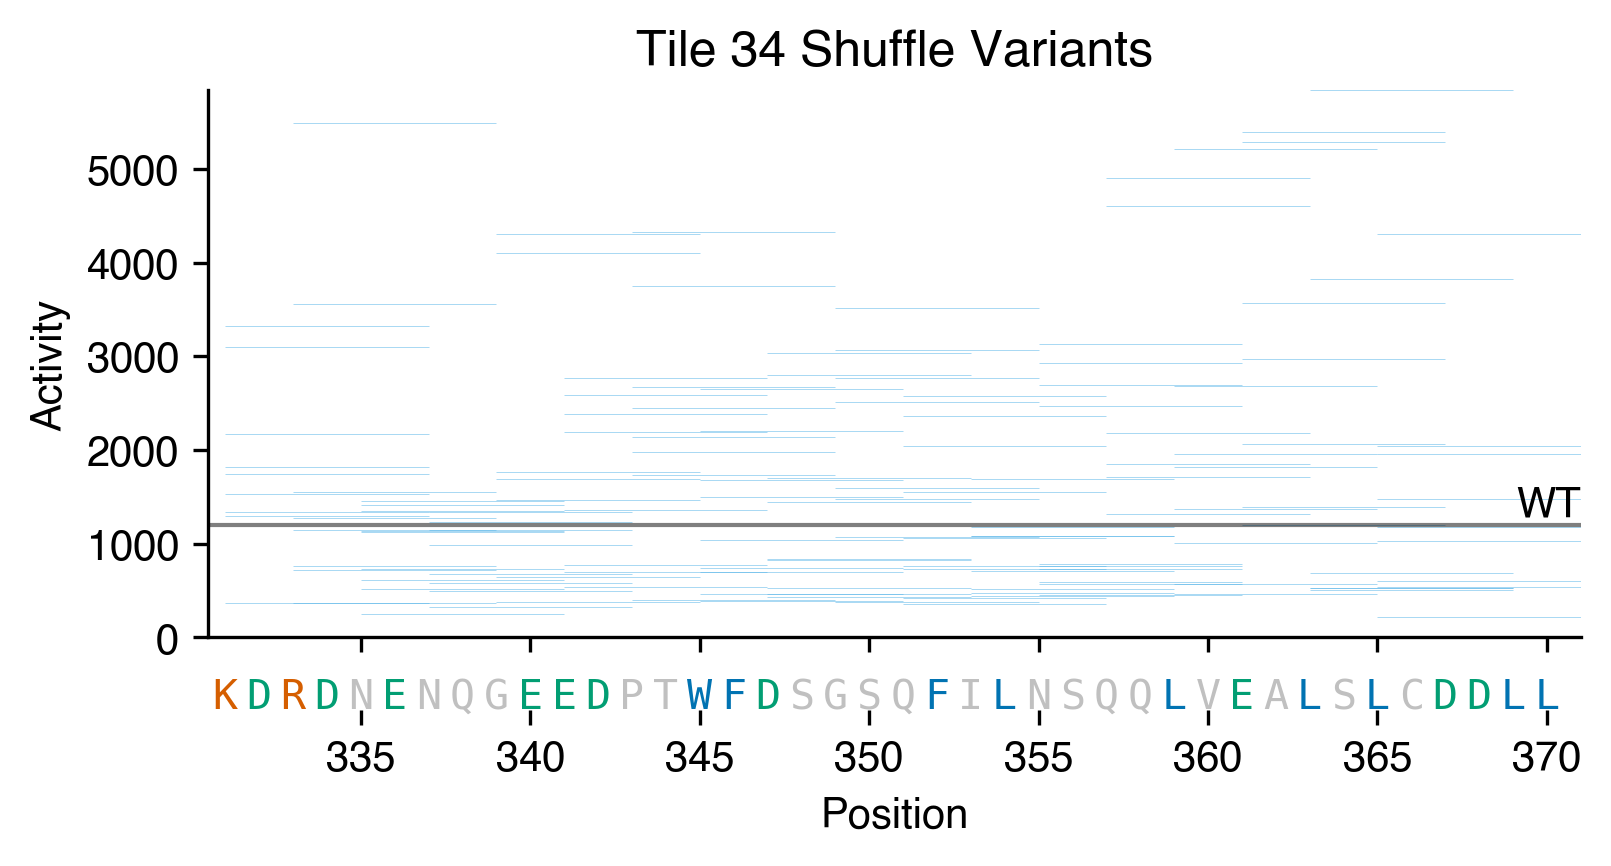

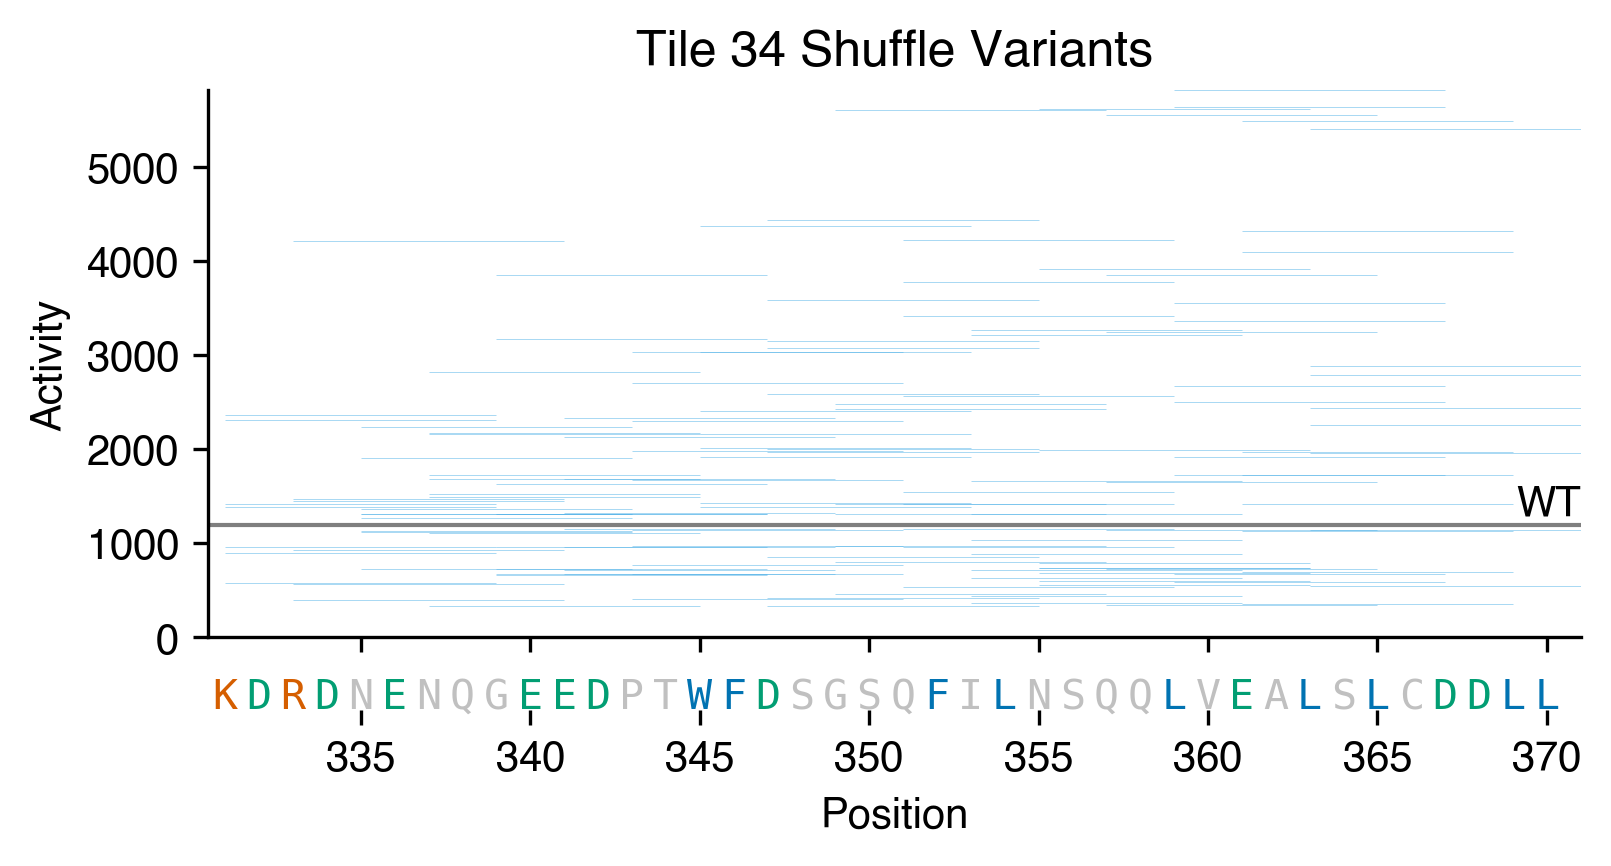

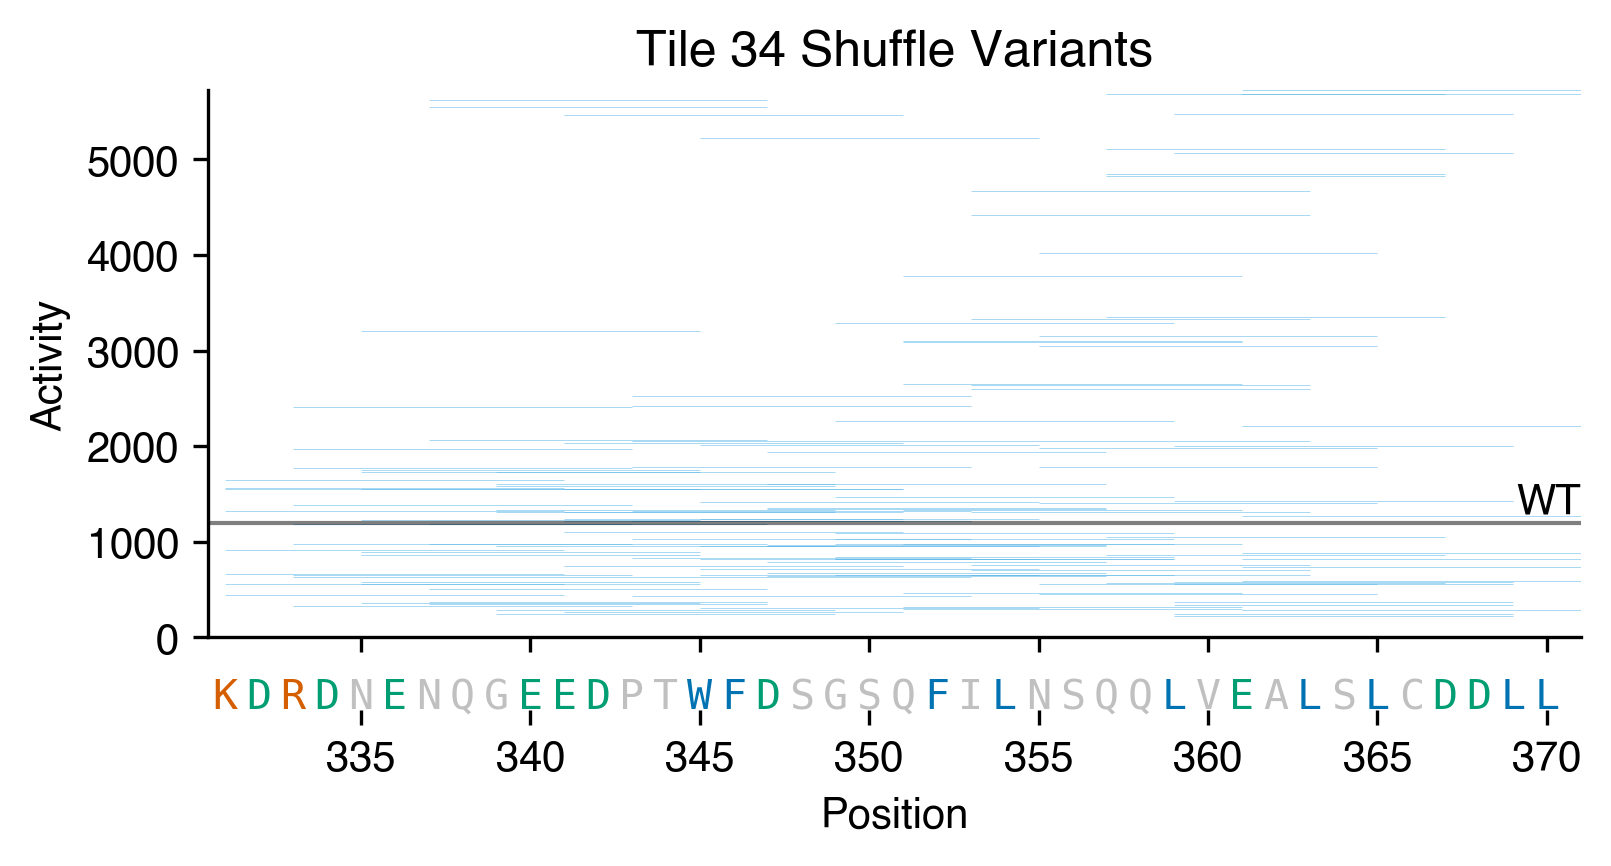

In [81]:
for shuffle_size in [2, 4, 6, 8, 10]:
    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 34]
    df = df[df["shuffle_size"] == shuffle_size]
    plot_shuffles(df)

# Alanines

In [82]:
Ascan = sog1_helpers.return_activities("Ascan")
Ascan_s = Ascan[~Ascan["Description"].str.contains("comb")]#["Other"].value_counts()
Ascan_s

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,3_Ascan_1-4,NaN,21,41,61,AAAADPRQVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN
1,3_Ascan_5-8,NaN,21,41,61,SASSAAAAVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN
2,3_Ascan_9-12,NaN,21,41,61,SASSDPRQAAAASNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN
3,3_Ascan_13-16,NaN,21,41,61,SASSDPRQVVWKAAAARHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN
4,3_Ascan_17-20,NaN,21,41,61,SASSDPRQVVWKSNPSAAAAKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
175,42_Ascan_21-24,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLAAAAFGSQDSFLAWGTGKTD,765.749755,949.328726,857.539240
176,42_Ascan_25-28,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEAAAADSFLAWGTGKTD,1774.478935,2653.535017,2214.006976
177,42_Ascan_29-32,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQAAAAAWGTGKTD,1805.524169,2867.177857,2336.351013
178,42_Ascan_33-36,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAAAAGKTD,798.435540,794.131502,796.283521


In [83]:
Ascan_s["tile_num"] = Ascan_s["Description"].str.split("_").str[0].astype(int)
Ascan_s["var_start"] = Ascan_s["Description"].str.split("_").str[-1].str.split("-").str[0].astype(int) + Ascan_s["Start"] - 1
Ascan_s["var_end"] = Ascan_s["Description"].str.split("_").str[-1].str.split("-").str[1].astype(int) + Ascan_s["Start"] - 1
Ascan_s["var_start"] = Ascan_s["var_start"].astype(int)
Ascan_s["var_end"] = Ascan_s["var_end"].astype(int)
Ascan_s = Ascan_s.dropna(subset = activity_col)
Ascan_s

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,tile_num,var_start,var_end
81,32_Ascan_5-8,NaN,311,331,351,LEHGAAAAAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,1508.477812,1848.864015,1678.670914,32,315,318
82,32_Ascan_9-12,NaN,311,331,351,LEHGLENGAAAALDDKEEQEKDRDNENQGEEDPTWFDSGS,248.868242,298.654151,273.761196,32,319,322
83,32_Ascan_13-16,NaN,311,331,351,LEHGLENGAKEMAAAAEEQEKDRDNENQGEEDPTWFDSGS,1122.089893,909.414996,1015.752444,32,323,326
85,32_Ascan_21-24,NaN,311,331,351,LEHGLENGAKEMLDDKEEQEAAAANENQGEEDPTWFDSGS,766.145196,621.165087,693.655141,32,331,334
86,32_Ascan_25-28,NaN,311,331,351,LEHGLENGAKEMLDDKEEQEKDRDAAAAGEEDPTWFDSGS,1328.108537,1321.275756,1324.692146,32,335,338
...,...,...,...,...,...,...,...,...,...,...,...,...
175,42_Ascan_21-24,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLAAAAFGSQDSFLAWGTGKTD,765.749755,949.328726,857.539240,42,430,433
176,42_Ascan_25-28,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEAAAADSFLAWGTGKTD,1774.478935,2653.535017,2214.006976,42,434,437
177,42_Ascan_29-32,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQAAAAAWGTGKTD,1805.524169,2867.177857,2336.351013,42,438,441
178,42_Ascan_33-36,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAAAAGKTD,798.435540,794.131502,796.283521,42,442,445


In [84]:
Ascan_s["tile_num"].value_counts()

tile_num
41    10
42     9
32     8
34     8
35     8
36     8
37     8
40     8
38     7
33     6
Name: count, dtype: int64

In [85]:
Ascan_s_with_diff = sog1_helpers.add_all_var_positions(Ascan_s, BasicArTh, activity_col, add_AAs = True)
Ascan_s_with_diff.head(3)

,Description_var,Other_var,Start,mid,End,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,tile_num,var_start,var_end,Description_wt,Other_wt,tile_wt,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs
0,32_Ascan_5-8,NaN,311,331,351,LEHGAAAAAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,1508.477812,1848.864015,1678.670914,32,315,318,BasicArTh.32,Q6NQK2,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,677.449029,1258.978627,968.213828,"[315, 316, 317, 318]","[L, E, N, G]"
1,32_Ascan_9-12,NaN,311,331,351,LEHGLENGAAAALDDKEEQEKDRDNENQGEEDPTWFDSGS,248.868242,298.654151,273.761196,32,319,322,BasicArTh.32,Q6NQK2,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,677.449029,1258.978627,968.213828,"[320, 321, 322]","[K, E, M]"
2,32_Ascan_13-16,NaN,311,331,351,LEHGLENGAKEMAAAAEEQEKDRDNENQGEEDPTWFDSGS,1122.089893,909.414996,1015.752444,32,323,326,BasicArTh.32,Q6NQK2,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,677.449029,1258.978627,968.213828,"[323, 324, 325, 326]","[L, D, D, K]"


In [86]:
def plot_tile_Ascan(tile):
    one_tile_Ascan = Ascan_s_with_diff[Ascan_s_with_diff["tile_num"] == tile]  
    
    fig, axs = plt.subplots(2, 1, sharex = True, figsize = (5,1.5), dpi = 300, gridspec_kw={'height_ratios': [1, 0.15]})

    ax1, ax2 = axs[0], axs[1]
    
    max_y = 0
    for i in range(len(one_tile_Ascan)):
        ax1.hlines(y=one_tile_Ascan[activity_col + "_var"].iloc[i], 
                   xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                   xmax=one_tile_Ascan["var_end"].iloc[i] + 0.5, 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-')
        max_y = max(max_y, one_tile_Ascan[activity_col + "_var"].iloc[i])
        

                           
    ax1.axhline(one_tile_Ascan[activity_col + "_wt"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)
    ax1.set_xlim(one_tile_Ascan["Start"].iloc[i] - 0.5, one_tile_Ascan["End"].iloc[i])    
    #ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile_Ascan["End"].iloc[i], y = one_tile_Ascan[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile_Ascan["Start"].iloc[i],
        one_tile_Ascan["End"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
                
    ax1.set_title("Tile " + str(tile) + ": Alanine Scan")
    plt.tight_layout(pad=0)

    sns.despine(ax = ax1, left = False)
    sns.despine(ax = ax2, left = True, bottom = True)

    # for pos in np.arange(one_tile_Ascan["Start"].iloc[i],
    #     one_tile_Ascan["End"].iloc[i] ):
    #     if (pos - one_tile_Ascan["Start"].iloc[i]) % 4 == 0:
    #         ax1.axvline(pos- 0.5, color = 'silver', alpha = 0.5)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax1.set_ylabel("Activity")
    ax2.set_xlabel("Position")


In [87]:
! mkdir ../output/figures/Ascan

mkdir: ../output/figures/Ascan: File exists


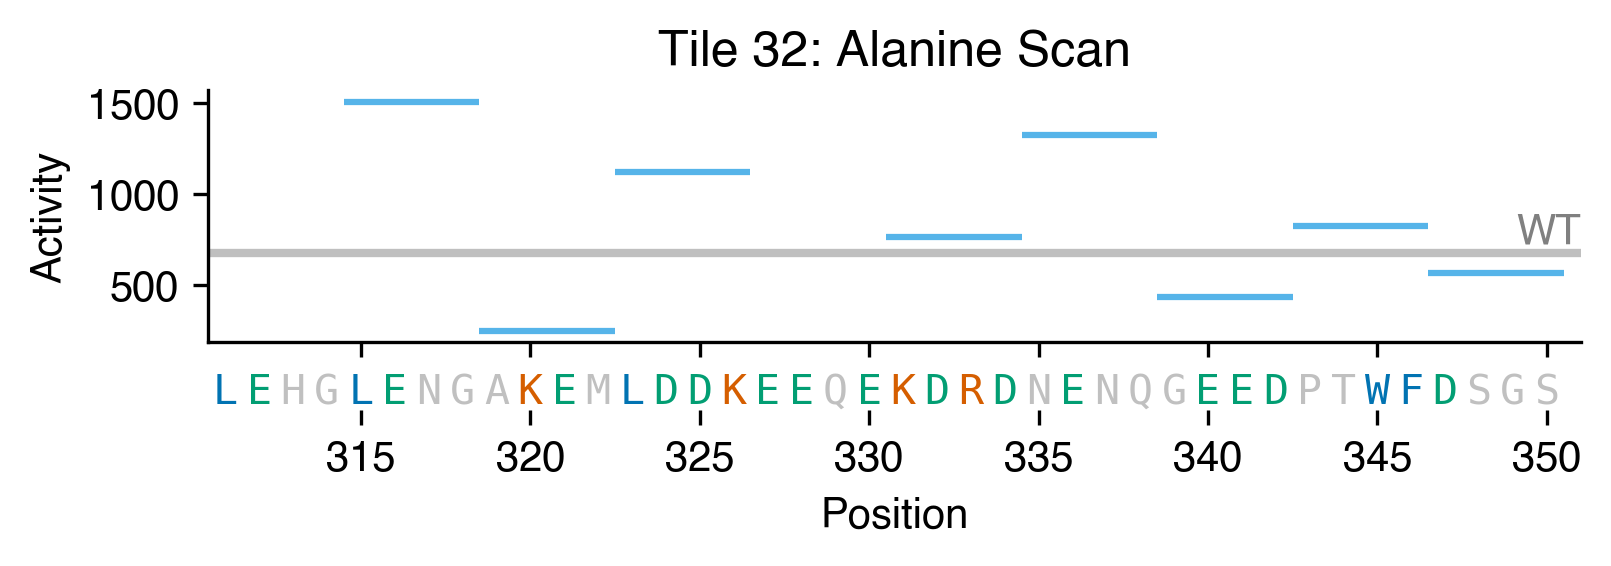

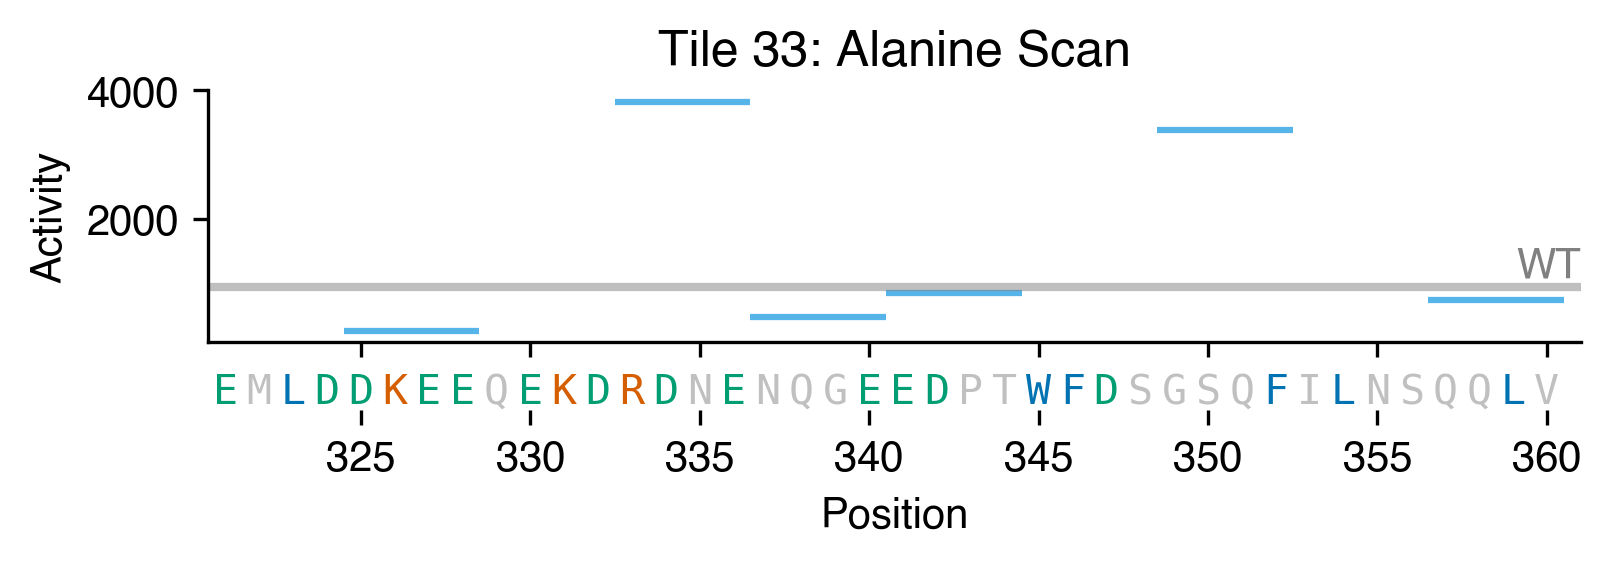

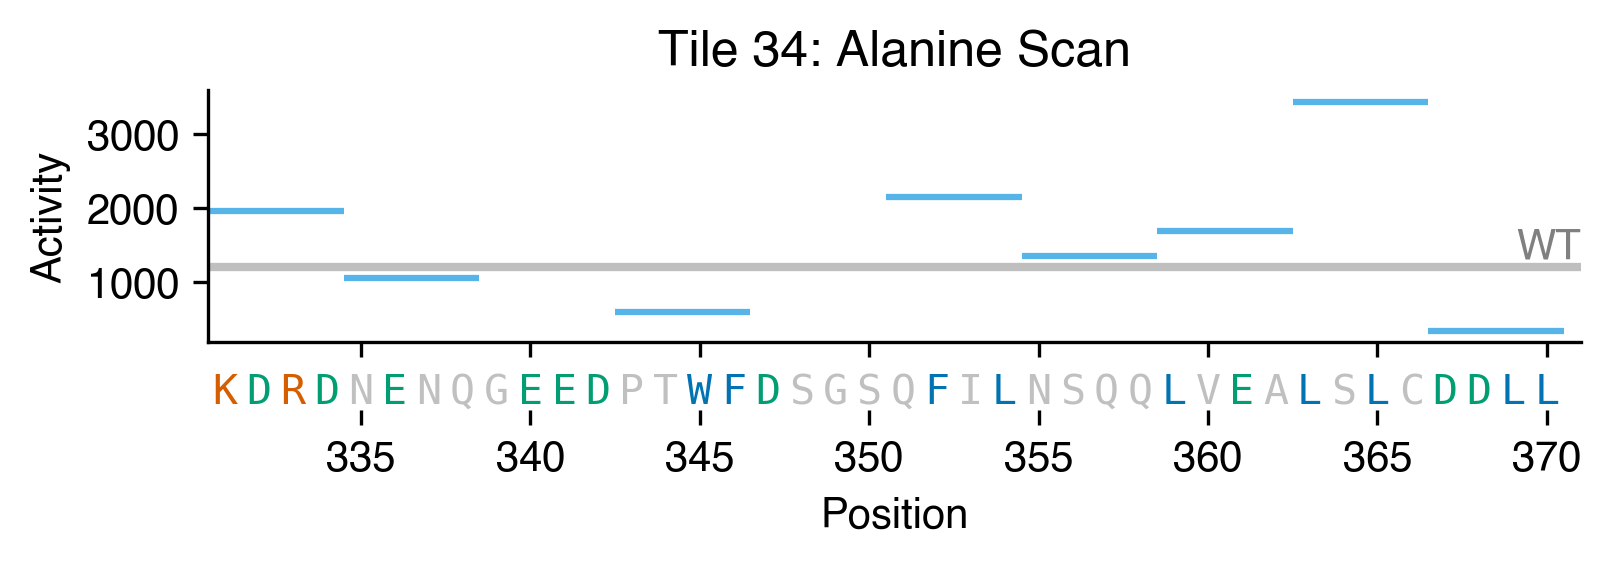

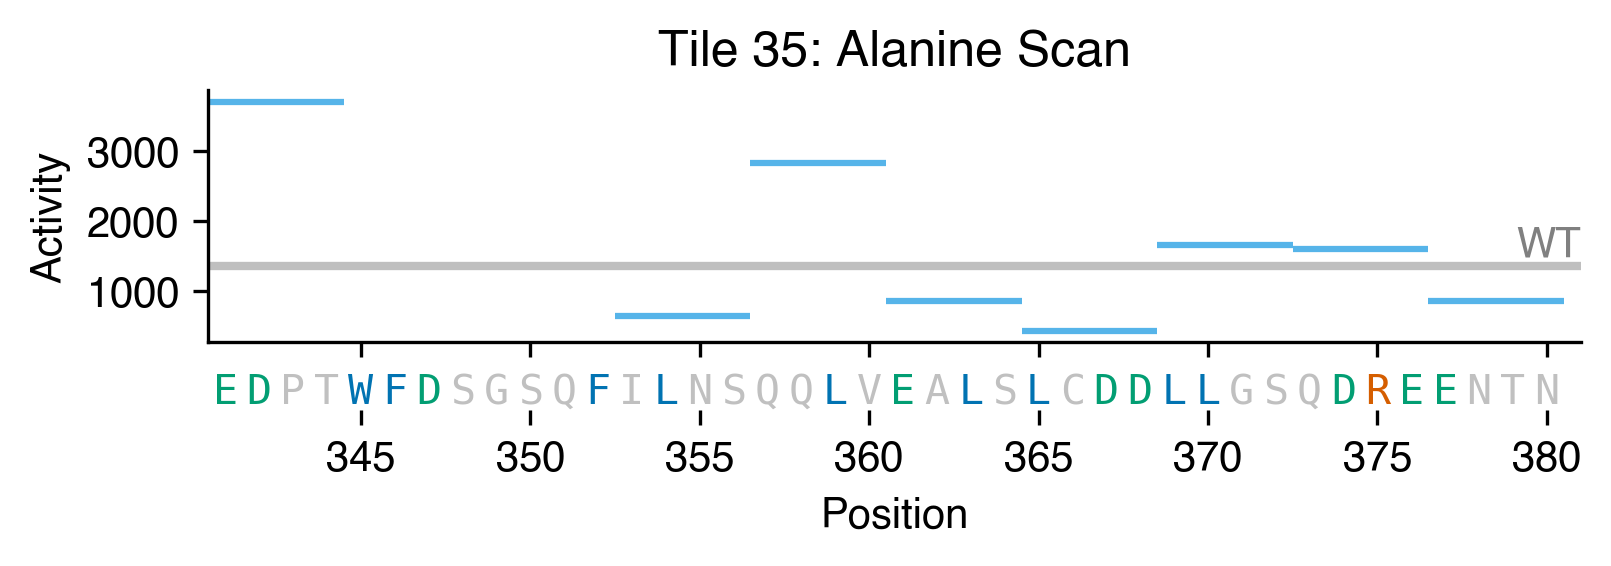

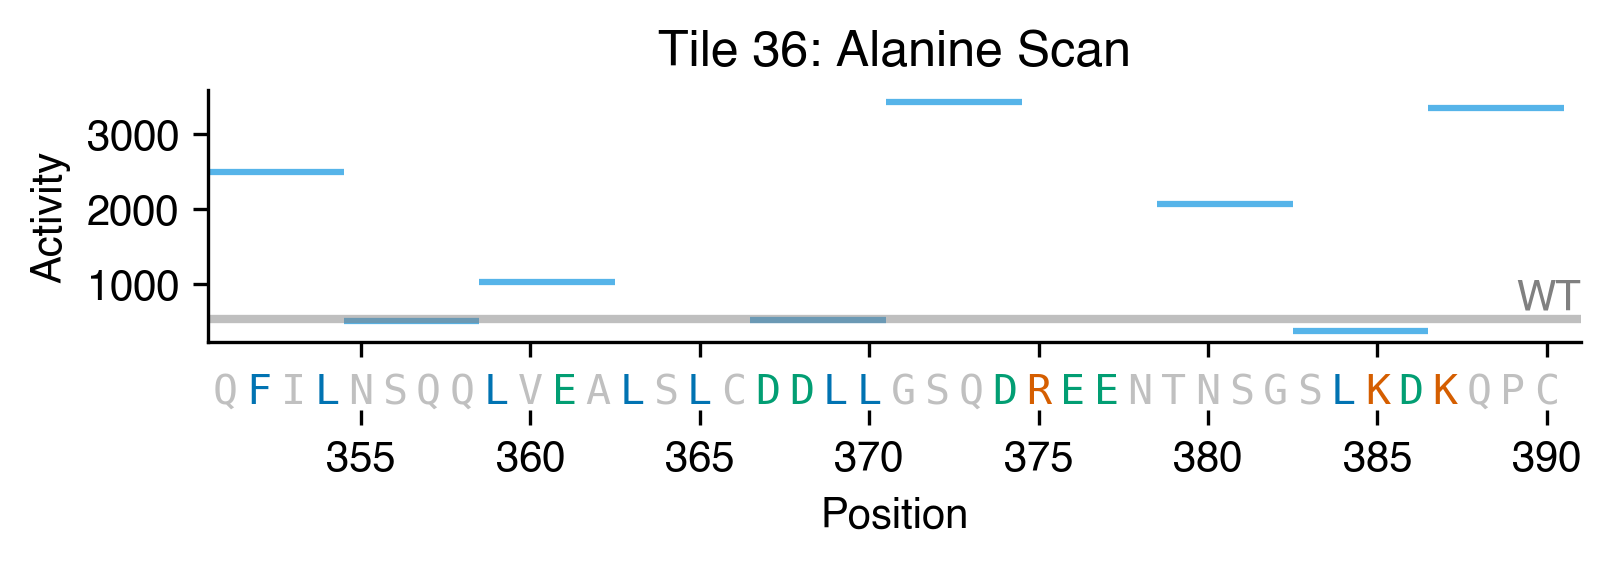

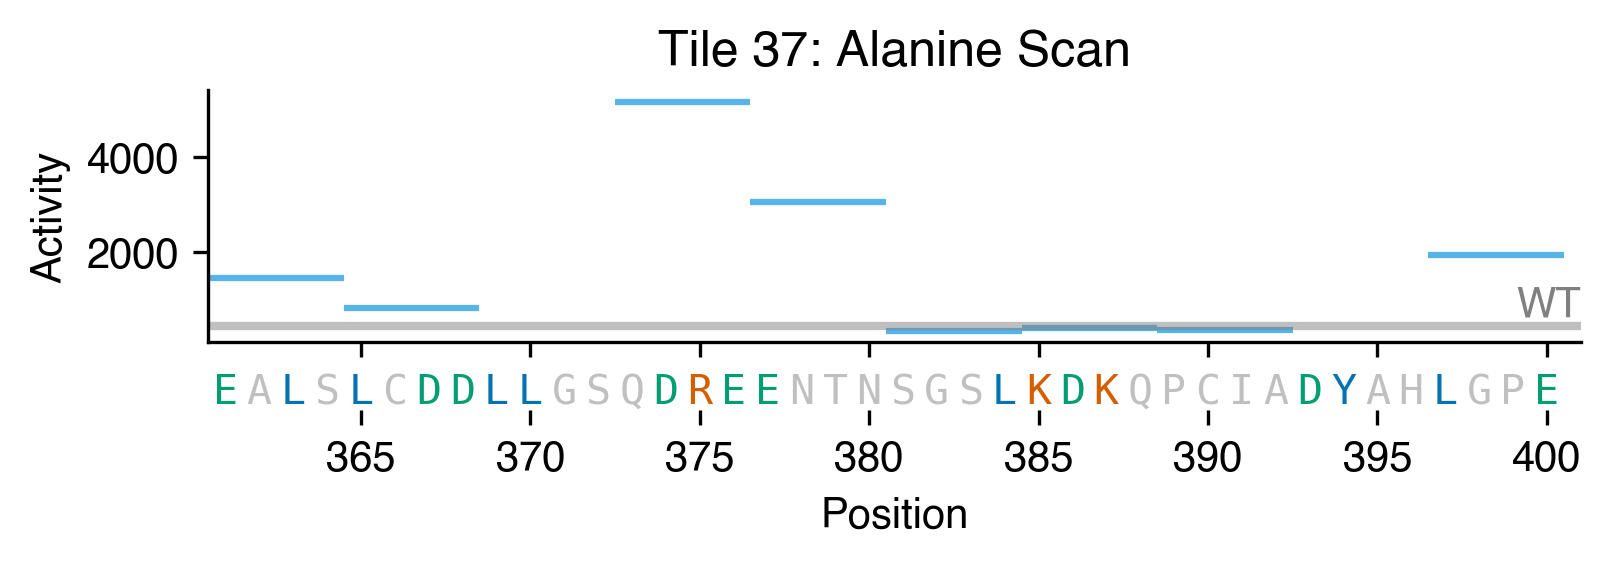

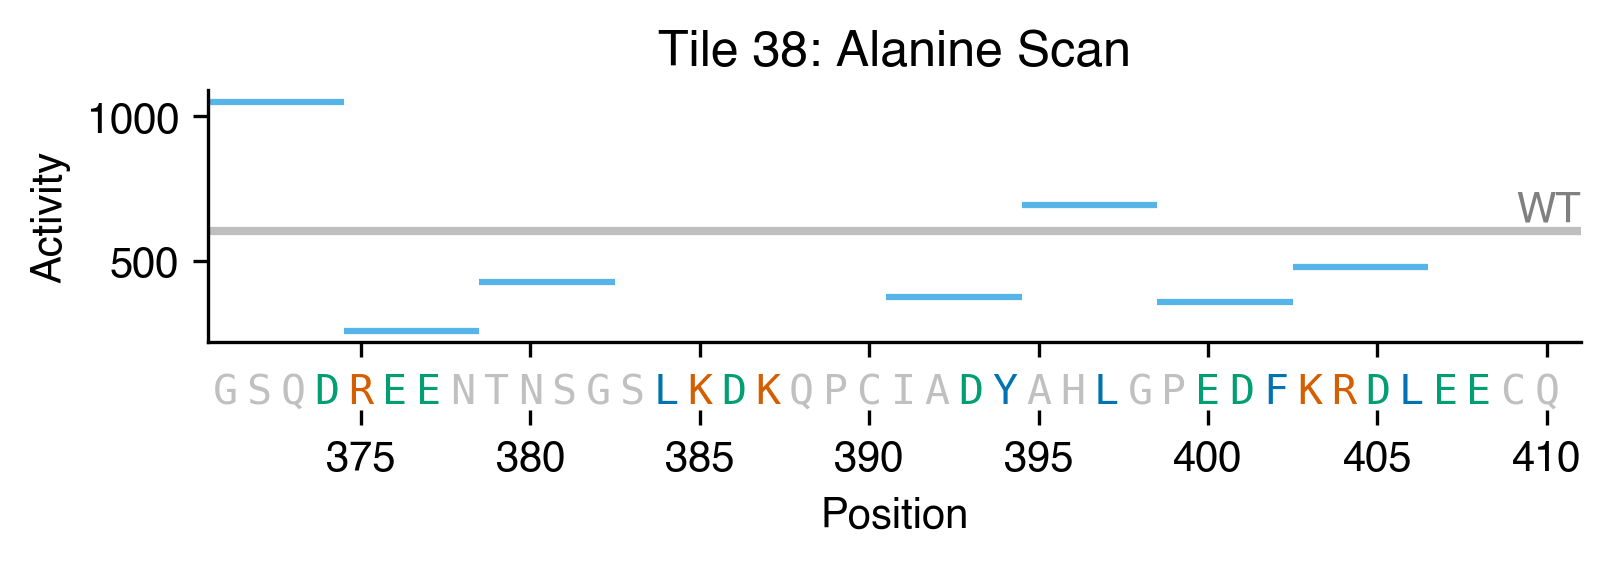

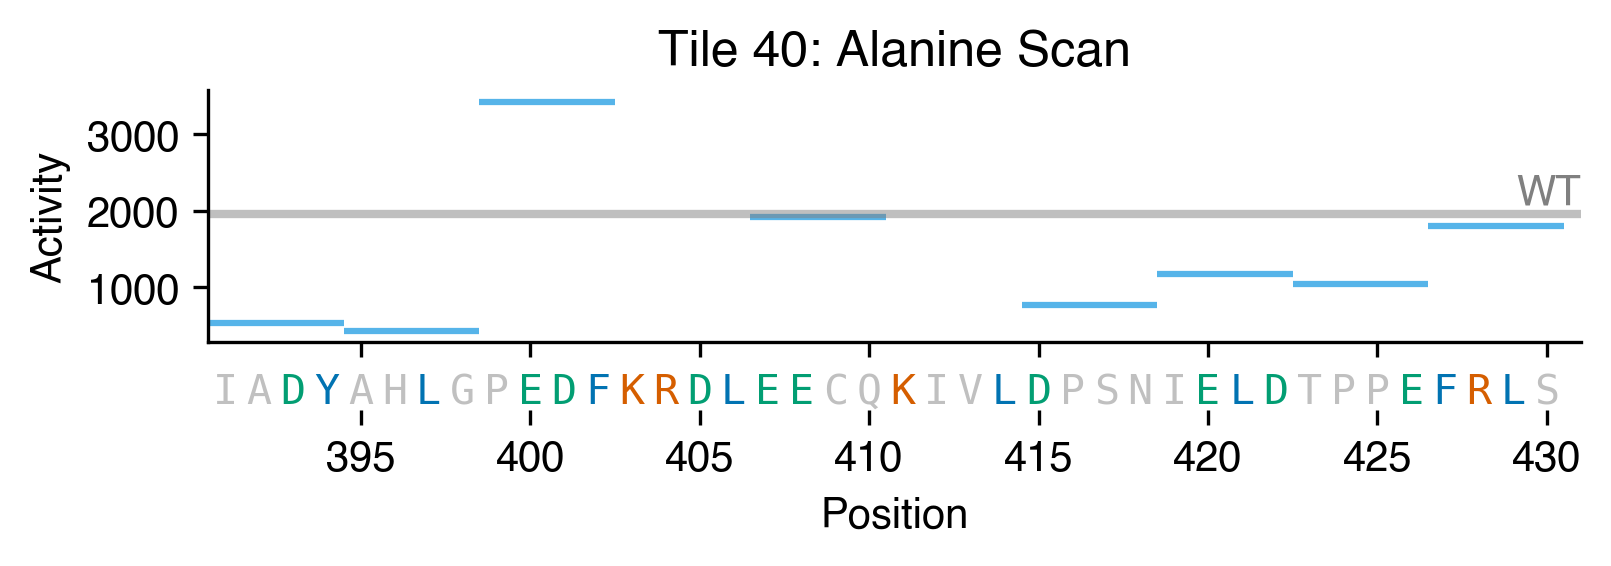

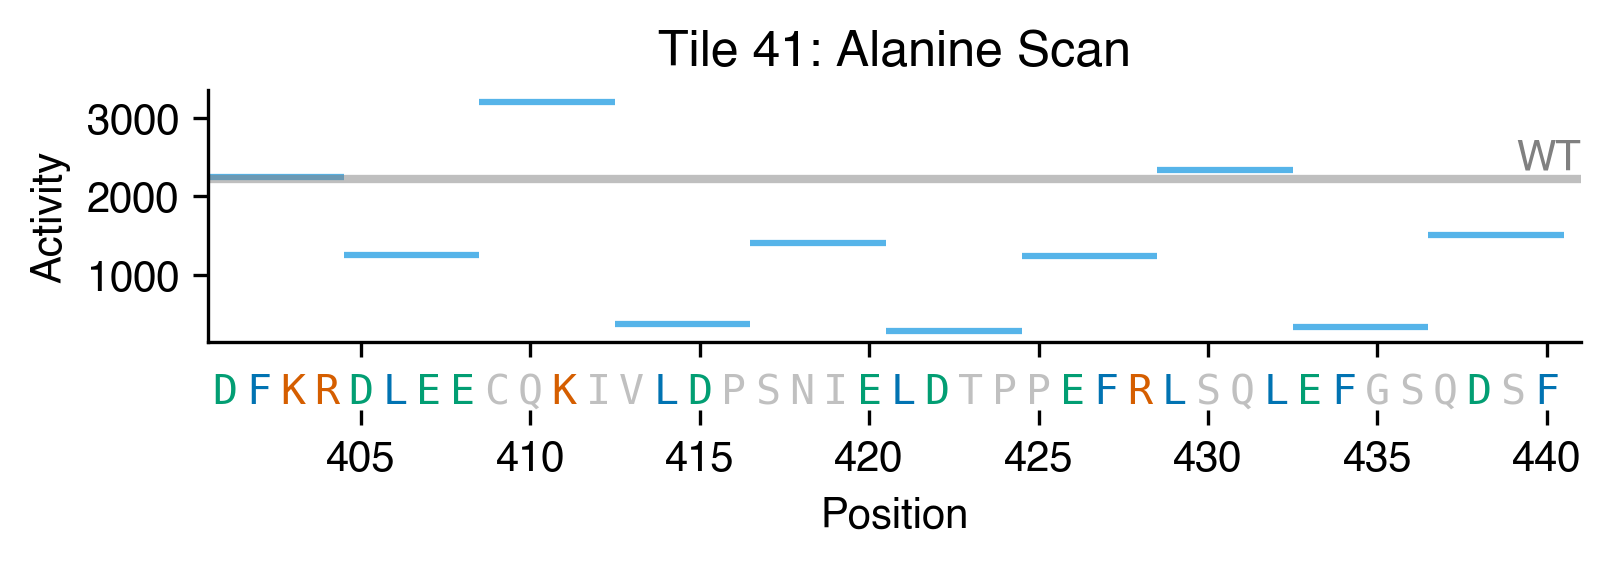

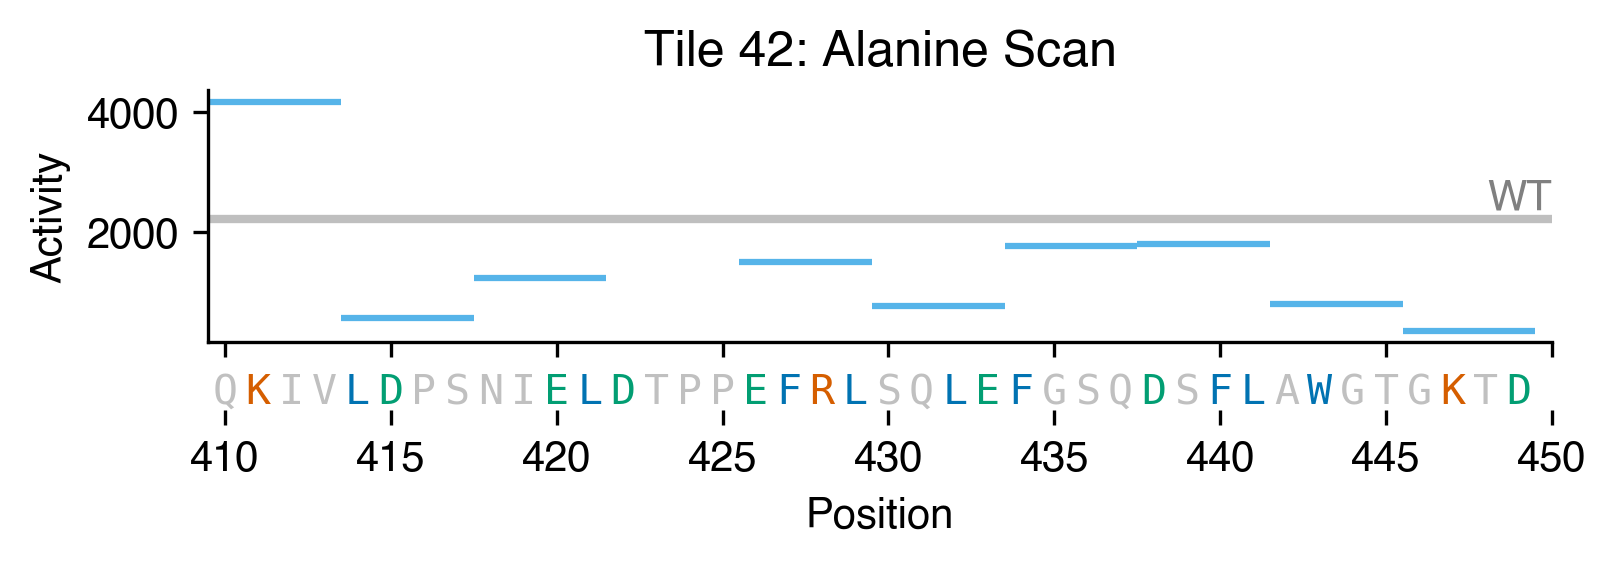

In [88]:
for i in Ascan_s["tile_num"].unique():
    plot_tile_Ascan(i)
    plt.savefig("../output/figures/Ascan/" + str(i) + ".png")

In [89]:
Ascan_s["tile_num"].unique()

array([32, 33, 34, 35, 36, 37, 38, 40, 41, 42])

In [90]:
Ascan_s["tile_num"].value_counts()

tile_num
41    10
42     9
32     8
34     8
35     8
36     8
37     8
40     8
38     7
33     6
Name: count, dtype: int64

# Add A scan below shuffle

In [91]:
def plot_shuffles_and_A_scan(tile):
    one_tile_shuffles = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile]
    
    fig, axs = plt.subplots(3, 1, sharex = True, figsize = (5,3), dpi = 300, gridspec_kw={'height_ratios': [1, 0.5, 0.1]})

    ax1, ax2, ax3 = axs[0], axs[1], axs[2]
    
    max_y = 0
    for i in range(len(one_tile_shuffles)):
        row_vars = one_tile_shuffles["vars"].iloc[i]
        ax1.hlines(y=one_tile_shuffles[activity_col + "_var"].iloc[i], 
                   xmin=min(row_vars), 
                   xmax=max(row_vars), 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-', alpha = 0.6, lw = 0.2)
        max_y = max(max_y, one_tile_shuffles[activity_col + "_var"].iloc[i])
        
    ax1.axhline(one_tile_shuffles[activity_col + "_wt"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)

    ax1.set_xlim(one_tile_shuffles["Start"].iloc[i] - 0.5, one_tile_shuffles["End"].iloc[i])    
    ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile_shuffles["End"].iloc[i], y = one_tile_shuffles[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile_shuffles["Start"].iloc[i],
        one_tile_shuffles["End"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax3.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')
                
    ax1.set_title("Tile " + str(one_tile_shuffles["tile"].iloc[i]))
    plt.tight_layout(pad=0)


    ax3.set_yticks([])
    ax1.set_ylabel("Shuffle\nActivity", rotation = 0, labelpad = 25)
    ax2.set_ylabel("Alanine\nScan\nActivity", rotation = 0, labelpad = 25)
    ax3.set_xlabel("Position")



    one_tile_Ascan = Ascan_s_with_diff[Ascan_s_with_diff["tile_num"] == tile]  
    

    max_y = 0
    for i in range(len(one_tile_Ascan)):
        ax2.hlines(y=one_tile_Ascan[activity_col + "_var"].iloc[i], 
                   xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                   xmax=one_tile_Ascan["var_end"].iloc[i] + 0.5, 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-')
        max_y = max(max_y, one_tile_Ascan[activity_col + "_var"].iloc[i])
        

                           
    ax2.axhline(one_tile_Ascan[activity_col + "_wt"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)
    ax2.text(x = one_tile_Ascan["End"].iloc[i], y = one_tile_Ascan[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")

    sns.despine()
    sns.despine(ax = ax3, left = True, bottom = True)

    x_ticks = np.arange(one_tile_shuffles["Start"].iloc[i], one_tile_shuffles["End"].iloc[i], 4)
    ax1.set_xticks(x_ticks, x_ticks)

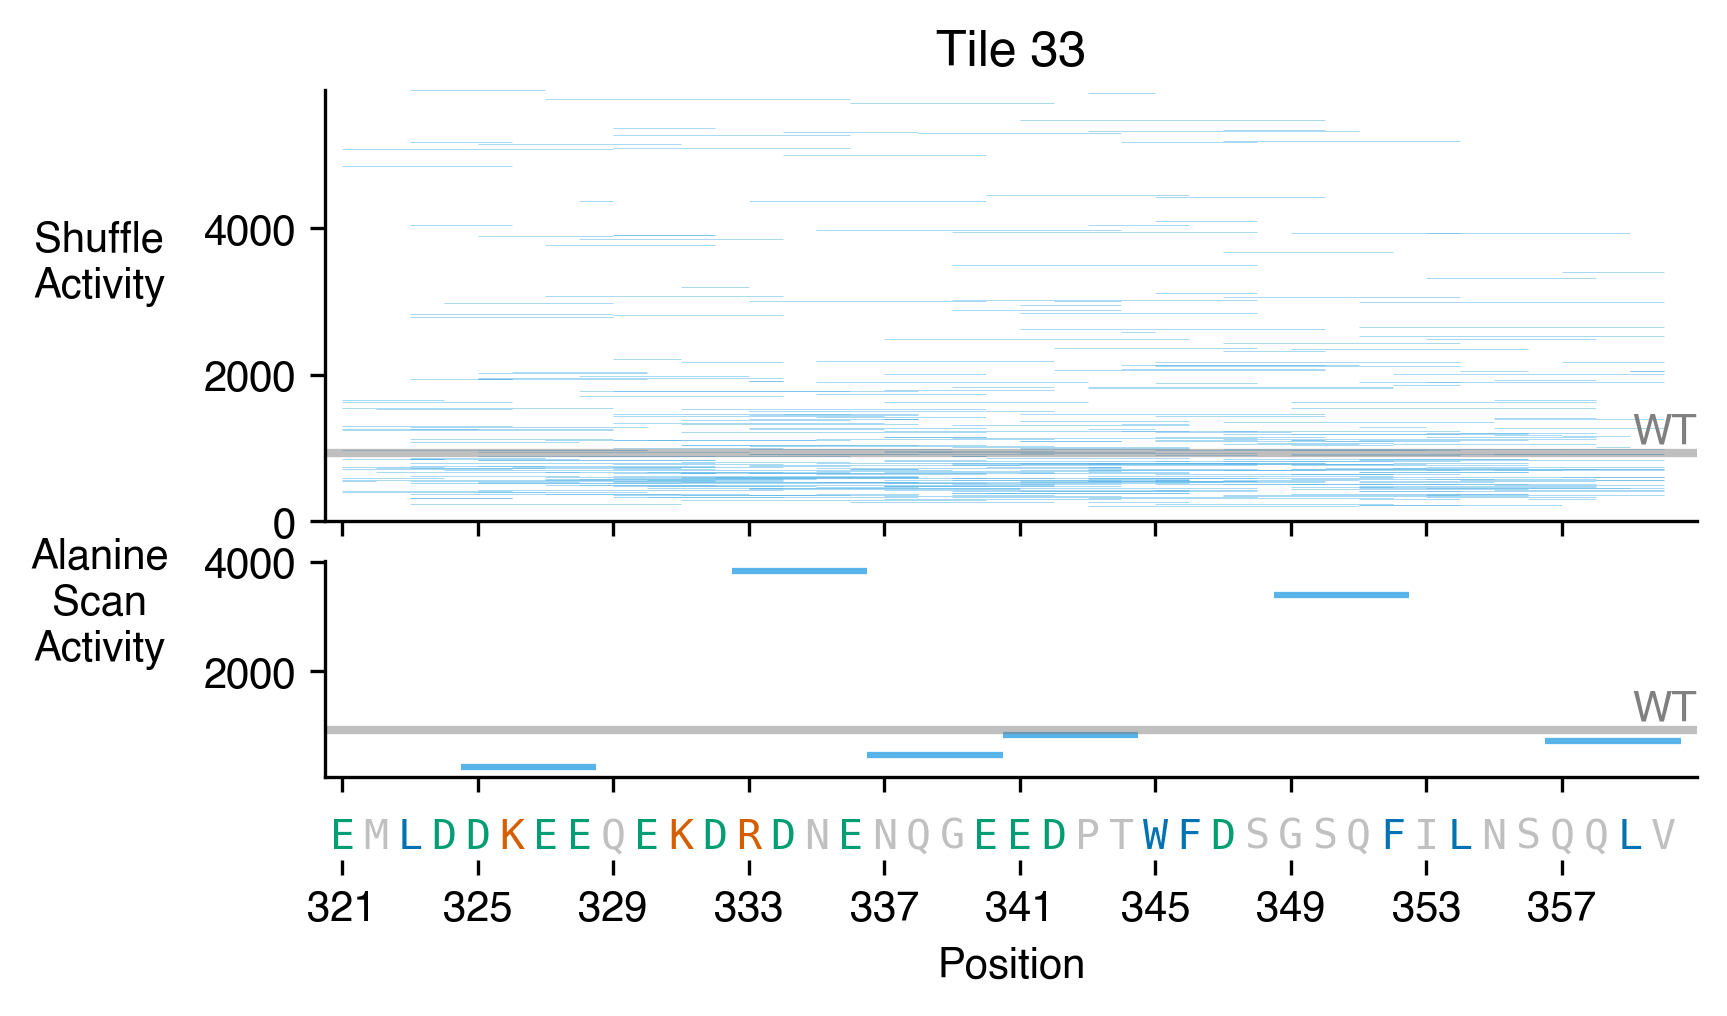

In [92]:
plot_shuffles_and_A_scan(33)

In [93]:
! mkdir ../output/figures/shuffles_and_Ascan/

mkdir: ../output/figures/shuffles_and_Ascan/: File exists


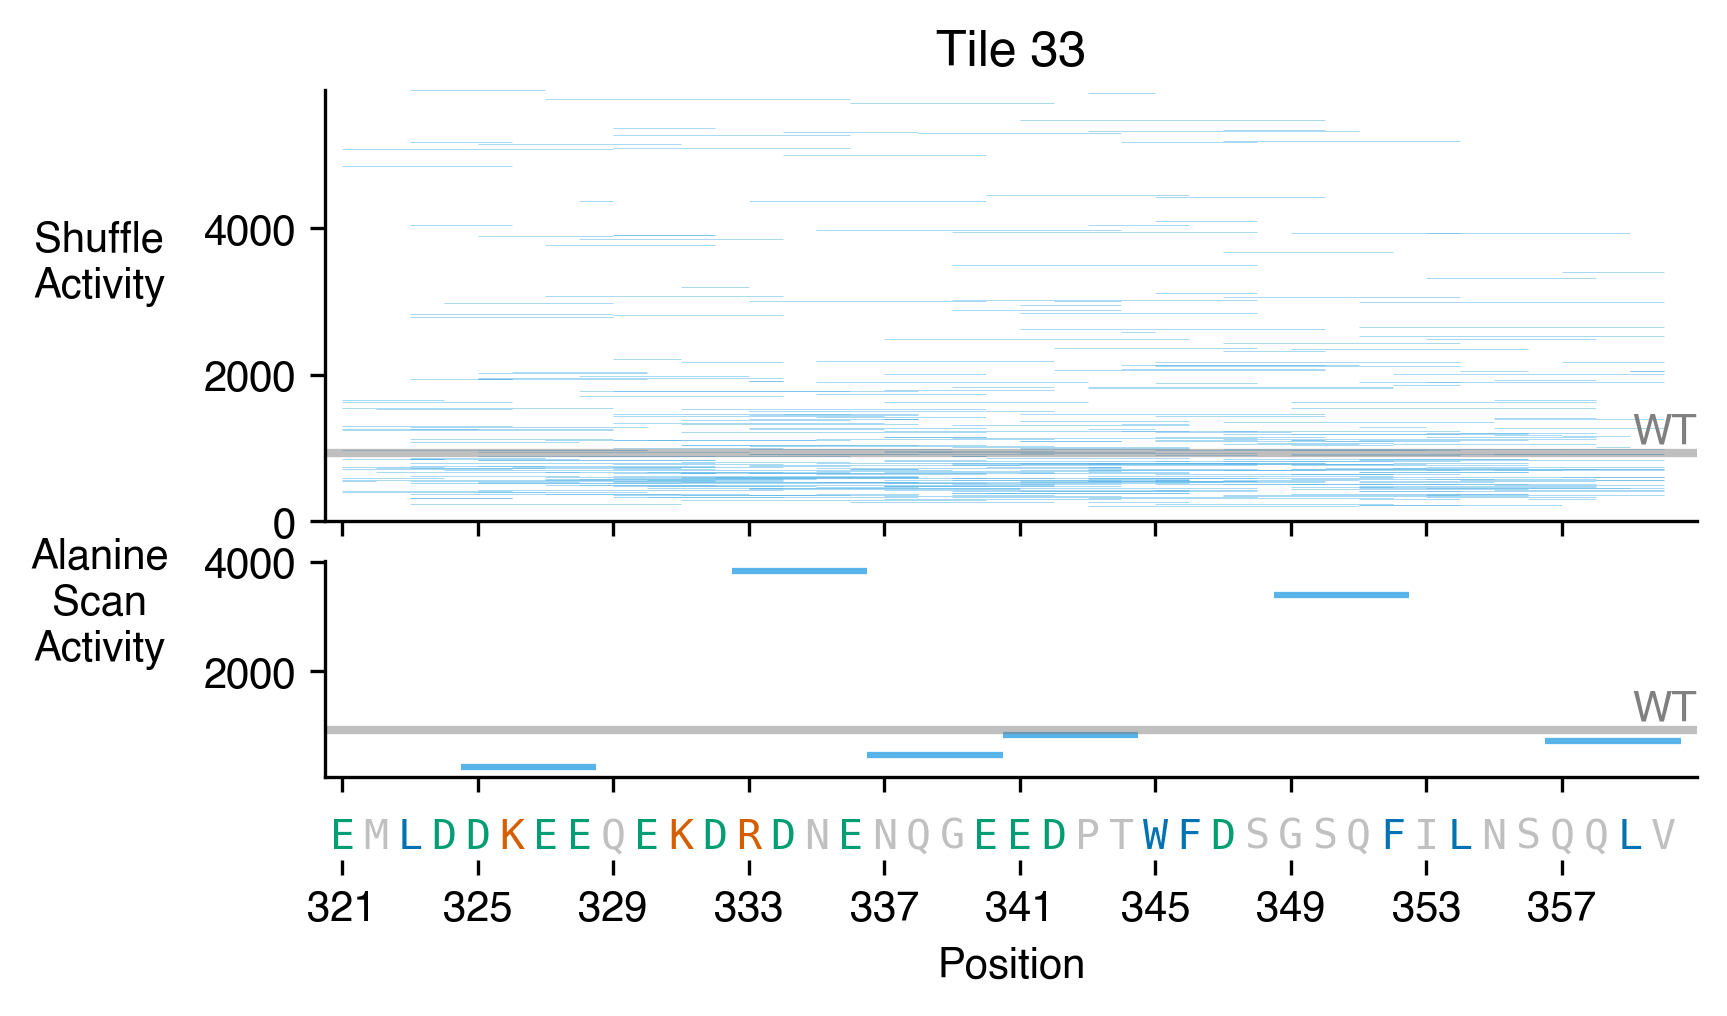

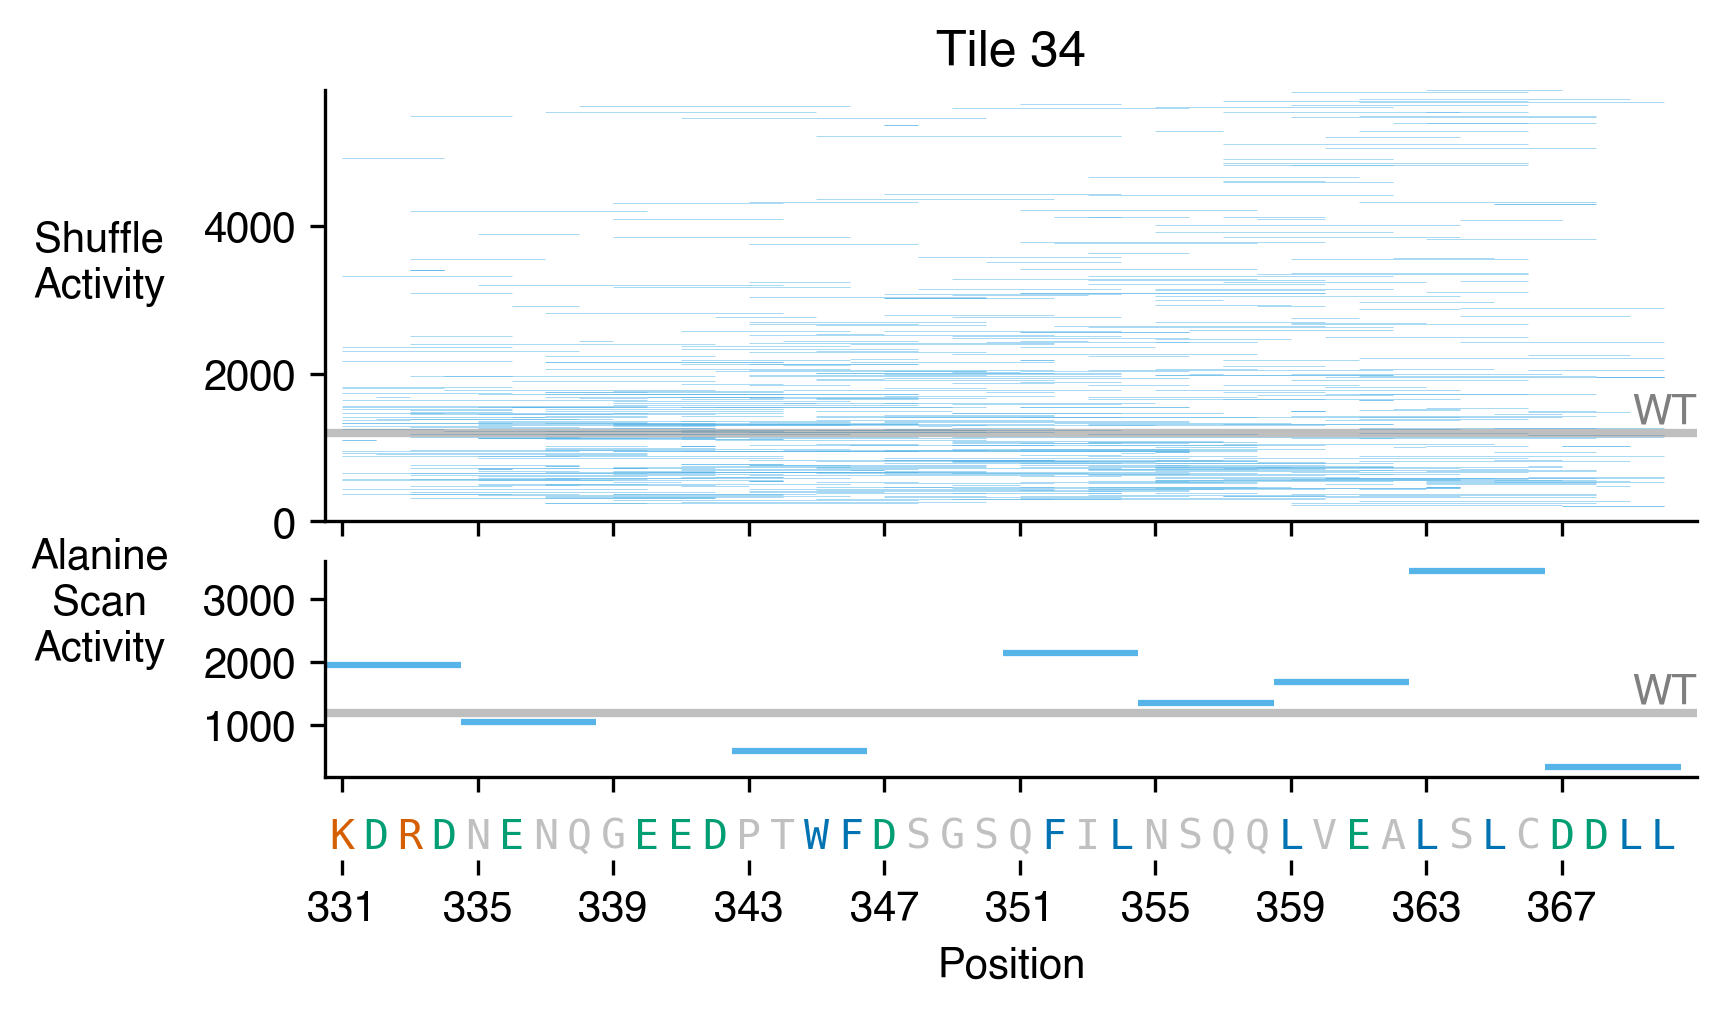

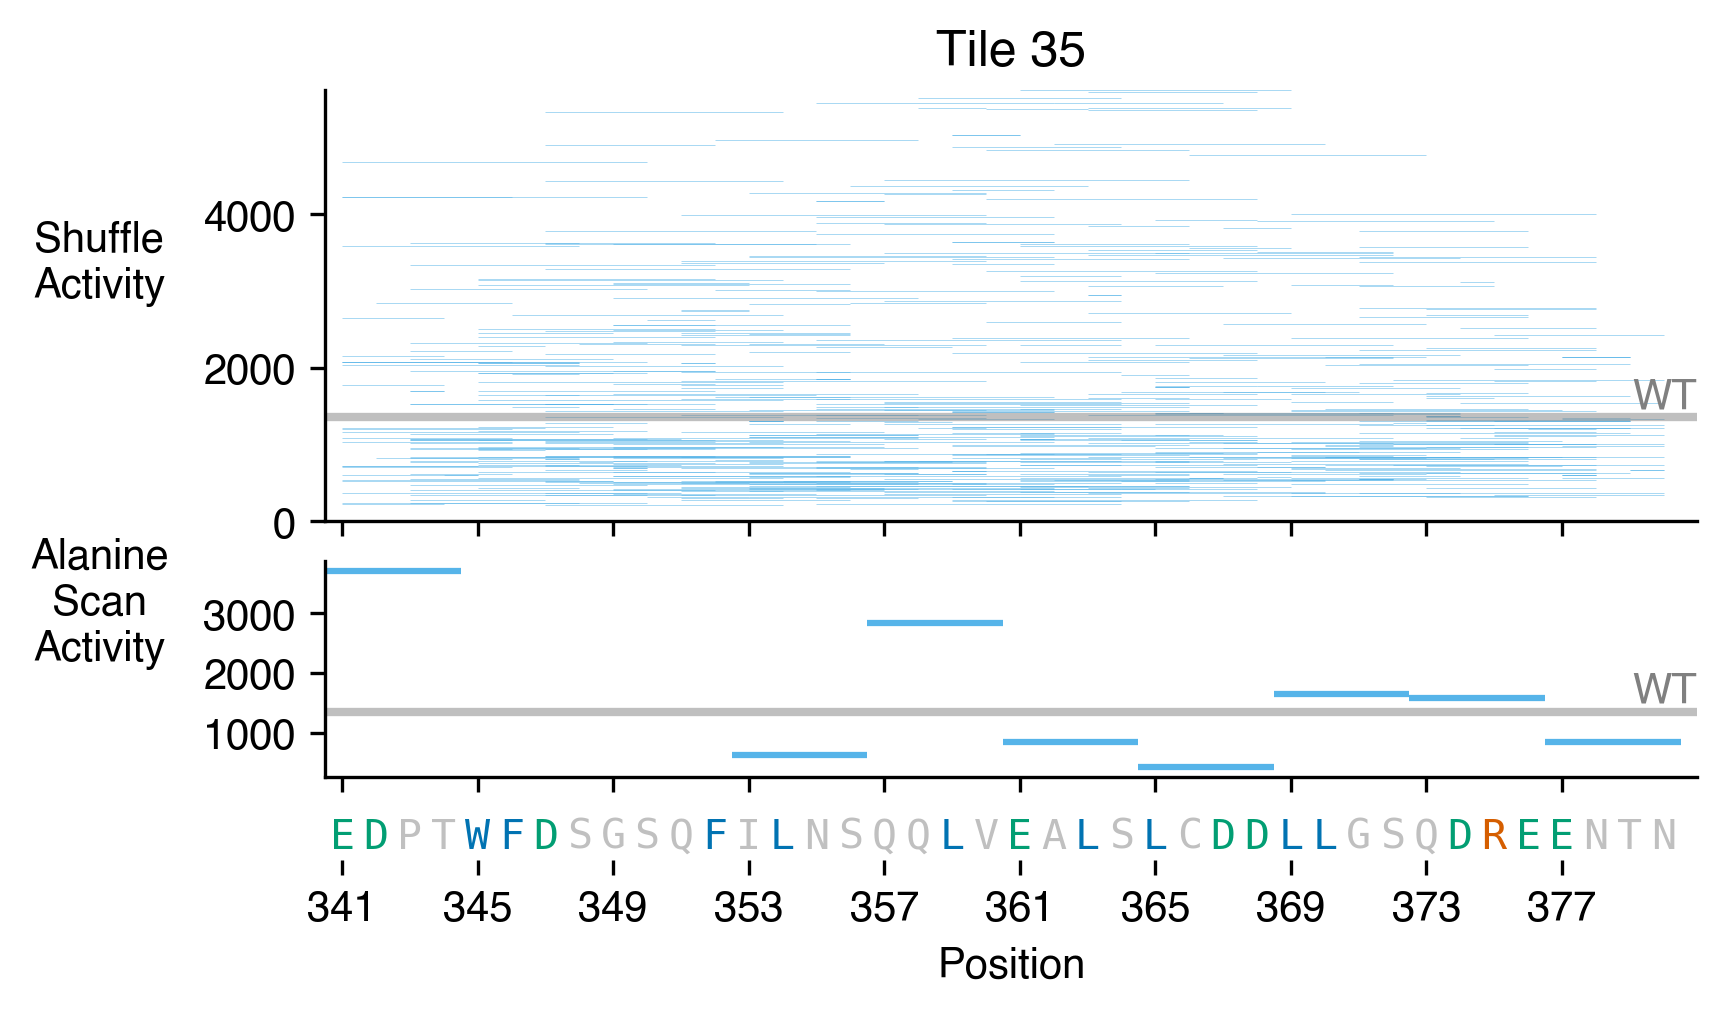

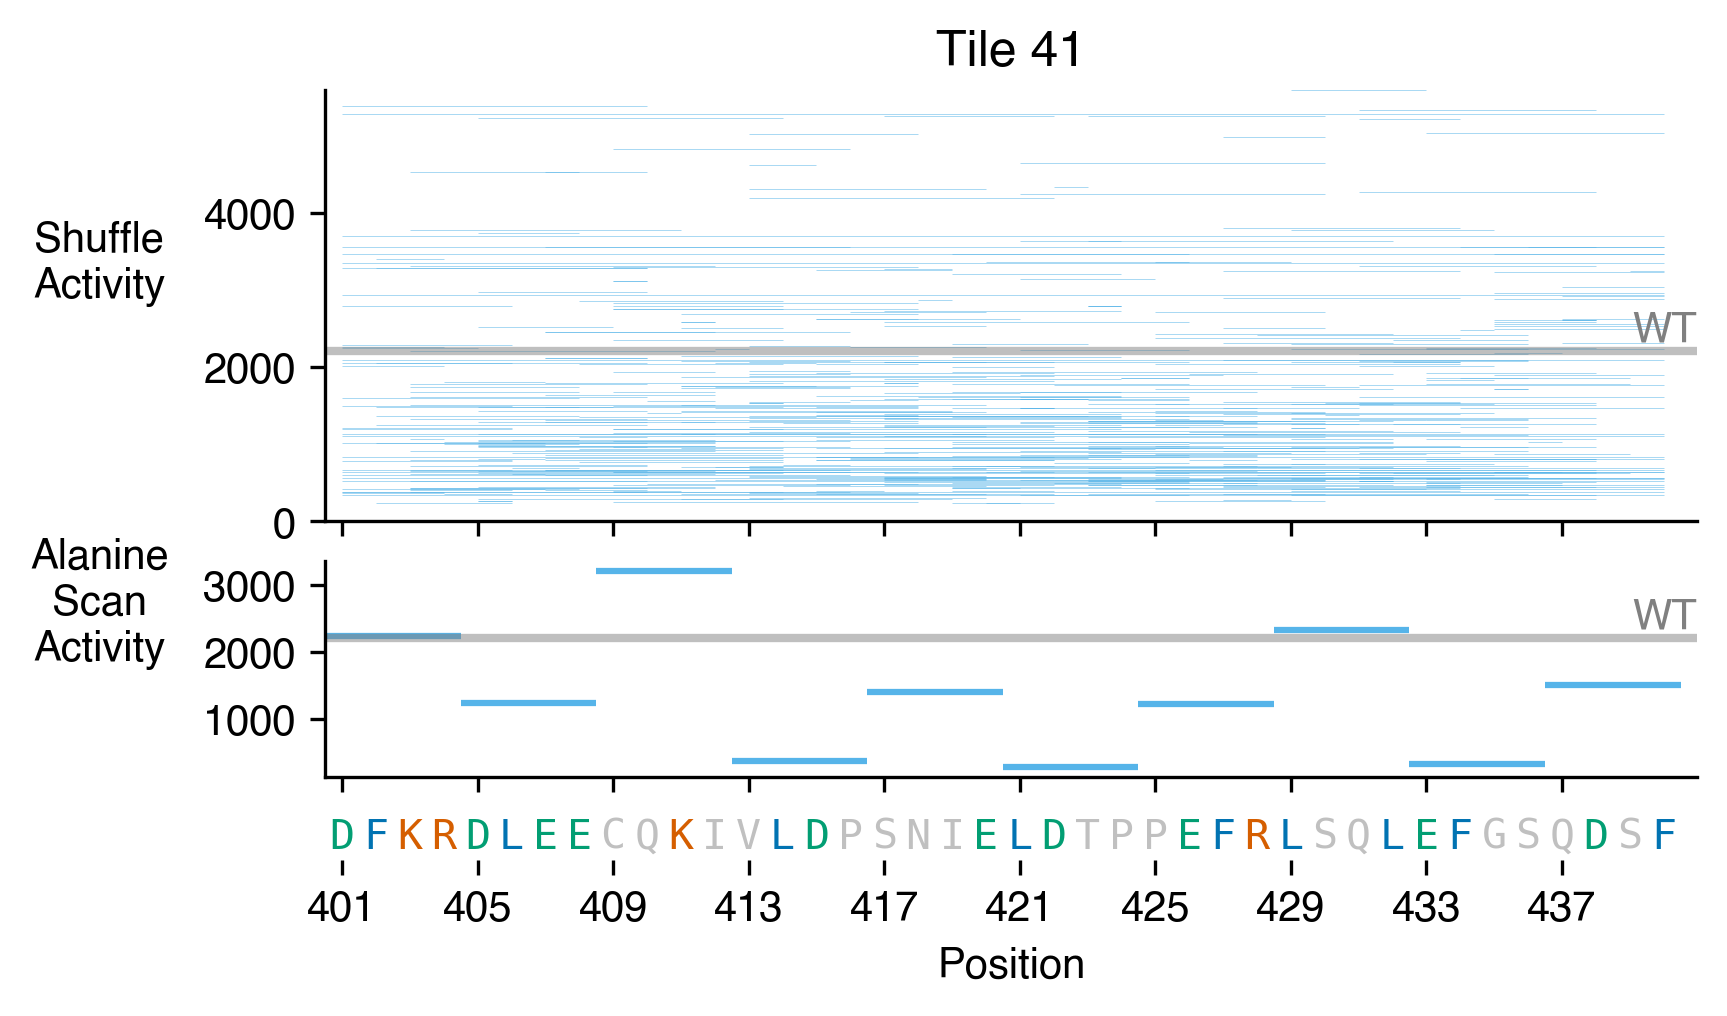

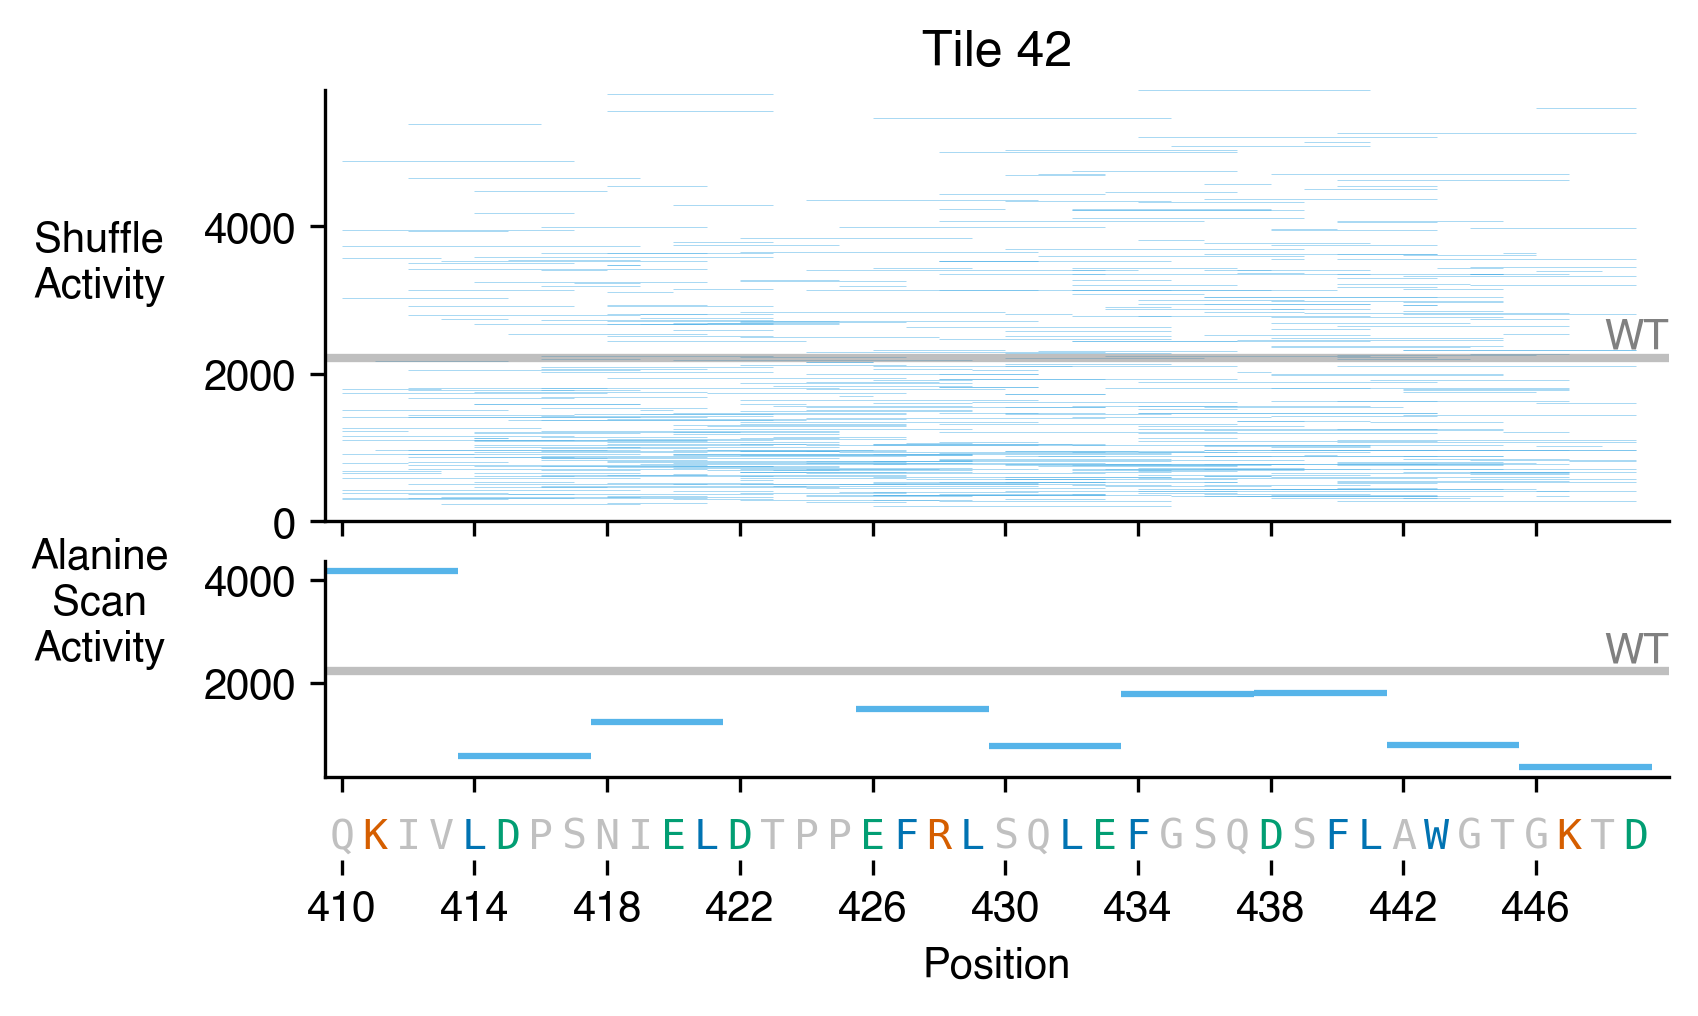

In [94]:
for tile_num in list(set(shuffle_vars_with_diff["tile"]) & set(Ascan_s_with_diff["tile_num"])):
    plot_shuffles_and_A_scan(tile_num)
    plt.savefig("../output/figures/shuffles_and_Ascan/" + str(tile_num) + ".png")

# A scan and shuffles

In [116]:
Ascan_s_with_diff["var_end_adj"] = Ascan_s_with_diff["var_end"] + 1
Ascan_s_with_diff[["var_start", "var_end_adj", "tile_num"]]

,var_start,var_end_adj,tile_num
0,315,319,32
1,319,323,32
2,323,327,32
3,331,335,32
4,335,339,32
...,...,...,...
75,430,434,42
76,434,438,42
77,438,442,42
78,442,446,42


In [117]:
shuffle_vars_with_diff["tile_num"] = shuffle_vars_with_diff["Description_var"].str.split("_").str[0].astype(int)
shuffle_vars_with_diff[["pos_start", "pos_end", "tile_num"]]

,pos_start,pos_end,tile_num
0,321,323,33
1,323,325,33
2,325,327,33
3,329,331,33
4,331,333,33
...,...,...,...
3568,440,450,42
3569,440,450,42
3570,440,450,42
3571,440,450,42


In [118]:
shuffle_Ascan_lined_up = pd.merge(Ascan_s_with_diff, 
         shuffle_vars_with_diff, 
         suffixes = ("_A", "_shuffle"), 
         left_on = ["var_start", "var_end_adj", "tile_num"], 
         right_on = ["pos_start", "pos_end", "tile_num"])
shuffle_Ascan_lined_up

,Description_var_A,Other_var_A,Start_A,mid_A,End_A,tile_var_A,Activity_S3_1_var_A,Activity_S3_2_var_A,lib2_avg_var_A,tile_num,...,Activity_S3_1_wt_shuffle,Activity_S3_2_wt_shuffle,lib2_avg_wt_shuffle,vars_shuffle,AAs_shuffle,tile,shuffle_size,coordinates,pos_start,pos_end
0,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327, 328]","[D, K, E, E]",33,4,2_1,325,329
1,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327]","[D, K, E]",33,4,2_2,325,329
2,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327, 328]","[D, K, E, E]",33,4,2_3,325,329
3,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[326, 328]","[K, E]",33,4,2_4,325,329
4,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327]","[D, K, E]",33,4,2_5,325,329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 448]","[G, T]",42,4,18_6,446,450
401,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 447, 448, 449]","[G, K, T, D]",42,4,18_7,446,450
402,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 447, 448, 449]","[G, K, T, D]",42,4,18_8,446,450
403,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 447, 449]","[G, K, D]",42,4,18_9,446,450


In [120]:
shuffle_Ascan_lined_up[["tile_var_A", "tile_var_shuffle"]]

,tile_var_A,tile_var_shuffle
0,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDEEKDQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
1,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDEDKEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
2,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDEEDKQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
3,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDDEEKQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
4,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDKEDEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
...,...,...
400,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTTKGD
401,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTTDKG
402,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTDGKT
403,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTKDTG


In [119]:
shuffle_Ascan_lined_up["Description_var_A"].value_counts()

Description_var_A
33_Ascan_5-8      10
35_Ascan_37-40    10
41_Ascan_5-8      10
41_Ascan_9-12     10
41_Ascan_13-16    10
41_Ascan_17-20    10
41_Ascan_21-24    10
41_Ascan_25-28    10
41_Ascan_29-32    10
41_Ascan_33-36    10
41_Ascan_37-40    10
42_Ascan_1-4      10
42_Ascan_5-8      10
42_Ascan_9-12     10
42_Ascan_17-20    10
42_Ascan_21-24    10
42_Ascan_25-28    10
42_Ascan_29-32    10
42_Ascan_33-36    10
41_Ascan_1-4      10
35_Ascan_33-36    10
33_Ascan_13-16    10
35_Ascan_29-32    10
33_Ascan_17-20    10
33_Ascan_21-24    10
33_Ascan_29-32    10
33_Ascan_37-40    10
34_Ascan_1-4      10
34_Ascan_5-8      10
34_Ascan_13-16    10
34_Ascan_21-24    10
34_Ascan_25-28    10
34_Ascan_29-32    10
34_Ascan_33-36    10
35_Ascan_1-4      10
35_Ascan_13-16    10
35_Ascan_17-20    10
35_Ascan_21-24    10
35_Ascan_25-28    10
42_Ascan_37-40    10
34_Ascan_37-40     5
Name: count, dtype: int64

In [53]:
shuffle_Ascan_lined_up["tile_num"].value_counts()

tile_num
34    180
35    160
33    140
32    130
36    100
41    100
42     90
37     60
40     50
38     30
Name: count, dtype: int64

In [54]:
shuffle_Ascan_lined_up[shuffle_Ascan_lined_up["tile_num"] == 34][["tile_var_A", "tile_var_shuffle"]]

,tile_var_A,tile_var_shuffle
270,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQERKDDNENQGEEDPTWFDSGSQFILNSQQLV
271,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQEKDDRNENQGEEDPTWFDSGSQFILNSQQLV
272,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQEDDRKNENQGEEDPTWFDSGSQFILNSQQLV
273,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQERDDKNENQGEEDPTWFDSGSQFILNSQQLV
274,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQEDRKDNENQGEEDPTWFDSGSQFILNSQQLV
...,...,...
445,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCLDDLGSQDREENTN
446,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCDLDLGSQDREENTN
447,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCLLDDGSQDREENTN
448,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCDLLDGSQDREENTN


In [124]:
shuffle_Ascan_lined_up.columns

Index(['Description_var_A', 'Other_var_A', 'Start_A', 'mid_A', 'End_A',
       'tile_var_A', 'Activity_S3_1_var_A', 'Activity_S3_2_var_A',
       'lib2_avg_var_A', 'tile_num', 'var_start', 'var_end',
       'Description_wt_A', 'Other_wt_A', 'tile_wt_A', 'Activity_S3_1_wt_A',
       'Activity_S3_2_wt_A', 'lib2_avg_wt_A', 'vars_A', 'AAs_A', 'var_end_adj',
       'Description_var_shuffle', 'Other_var_shuffle', 'Start_shuffle',
       'mid_shuffle', 'End_shuffle', 'tile_var_shuffle',
       'Activity_S3_1_var_shuffle', 'Activity_S3_2_var_shuffle',
       'lib2_avg_var_shuffle', 'Description_wt_shuffle', 'Other_wt_shuffle',
       'tile_wt_shuffle', 'Activity_S3_1_wt_shuffle',
       'Activity_S3_2_wt_shuffle', 'lib2_avg_wt_shuffle', 'vars_shuffle',
       'AAs_shuffle', 'tile', 'shuffle_size', 'coordinates', 'pos_start',
       'pos_end'],
      dtype='object')

In [220]:
def plot_tile_Ascan_and_shuffles(tile):
    one_tile = shuffle_Ascan_lined_up[shuffle_Ascan_lined_up["tile_num"] == tile]#[["var_start", "var_end_adj", "Activity_S3_1_var_A", "Activity_S3_1_var_shuffle"]]
    
    fig, axs = plt.subplots(2, 1, sharex = True, figsize = (5,1.5), dpi = 300, gridspec_kw={'height_ratios': [1, 0.15]})

    ax1, ax2 = axs[0], axs[1]


    one_tile_Ascan = one_tile[["var_start", "var_end_adj", "Activity_S3_1_var_A"]].drop_duplicates()
    
    max_y = 0

    label = "A Scan"
    
    for i in range(len(one_tile_Ascan)):
        if label:
            ax1.hlines(y=one_tile_Ascan["Activity_S3_1_var_A"].iloc[i], 
                       xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                       xmax=one_tile_Ascan["var_end_adj"].iloc[i] - 0.5, 
                       color=sns.color_palette('colorblind')[-1], 
                       linestyle='-', label = label)
            label = False
        else:
            ax1.hlines(y=one_tile_Ascan["Activity_S3_1_var_A"].iloc[i], 
                   xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                   xmax=one_tile_Ascan["var_end_adj"].iloc[i] - 0.5, 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-')
        
        max_y = max(max_y, one_tile_Ascan["Activity_S3_1_var_A"].iloc[i])

    label = "Shuffle"
        
    for i in range(len(one_tile)):
        if label:
            ax1.hlines(y=one_tile["Activity_S3_1_var_shuffle"].iloc[i], 
                       xmin=one_tile["var_start"].iloc[i] - 0.5, 
                       xmax=one_tile["var_end_adj"].iloc[i] - 0.5, 
                       color=sns.color_palette('colorblind')[1], 
                       linestyle='--', lw = 0.5, label = label)
            label = False
        else:
            ax1.hlines(y=one_tile["Activity_S3_1_var_shuffle"].iloc[i], 
                       xmin=one_tile["var_start"].iloc[i] - 0.5, 
                       xmax=one_tile["var_end_adj"].iloc[i] - 0.5, 
                       color=sns.color_palette('colorblind')[1], 
                       linestyle='--', lw = 0.5)
        max_y = max(max_y, one_tile["Activity_S3_1_var_shuffle"].iloc[i])

    ax1.legend(bbox_to_anchor = (1,1))
    
    ax1.axhline(one_tile[activity_col + "_wt_A"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)
    ax1.set_xlim(one_tile["Start_A"].iloc[i] - 0.5, one_tile["End_A"].iloc[i])    
    ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile["End_A"].iloc[i], y = one_tile[activity_col + "_wt_A"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile["Start_A"].iloc[i],
        one_tile["End_A"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
                
    ax1.set_title("Tile " + str(tile))
    plt.tight_layout(pad=0)

    sns.despine(ax = ax1, left = False)
    sns.despine(ax = ax2, left = True, bottom = True)

    # # for pos in np.arange(one_tile_Ascan["Start"].iloc[i],
    # #     one_tile_Ascan["End"].iloc[i] ):
    # #     if (pos - one_tile_Ascan["Start"].iloc[i]) % 4 == 0:
    # #         ax1.axvline(pos- 0.5, color = 'silver', alpha = 0.5)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax1.set_ylabel("Activity")
    ax2.set_xlabel("Position")


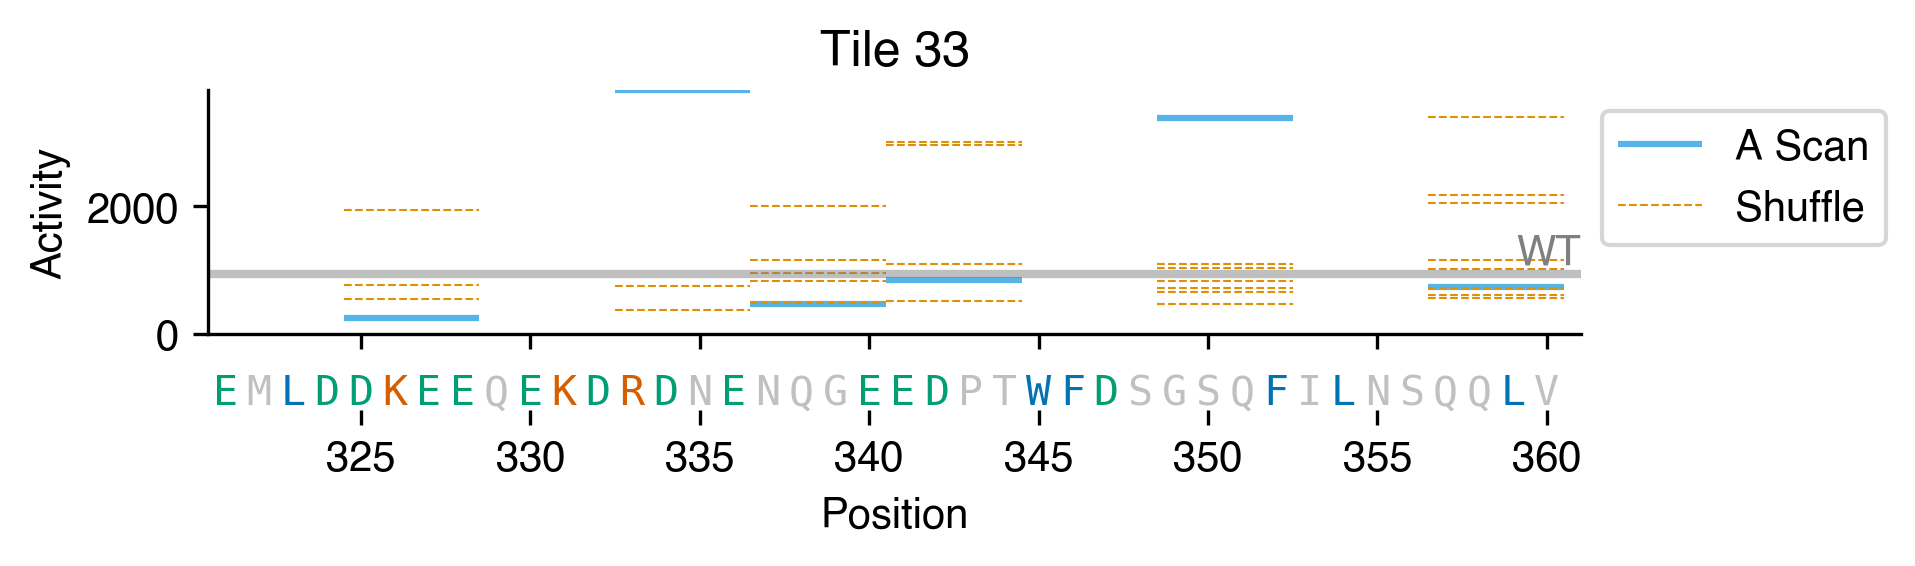

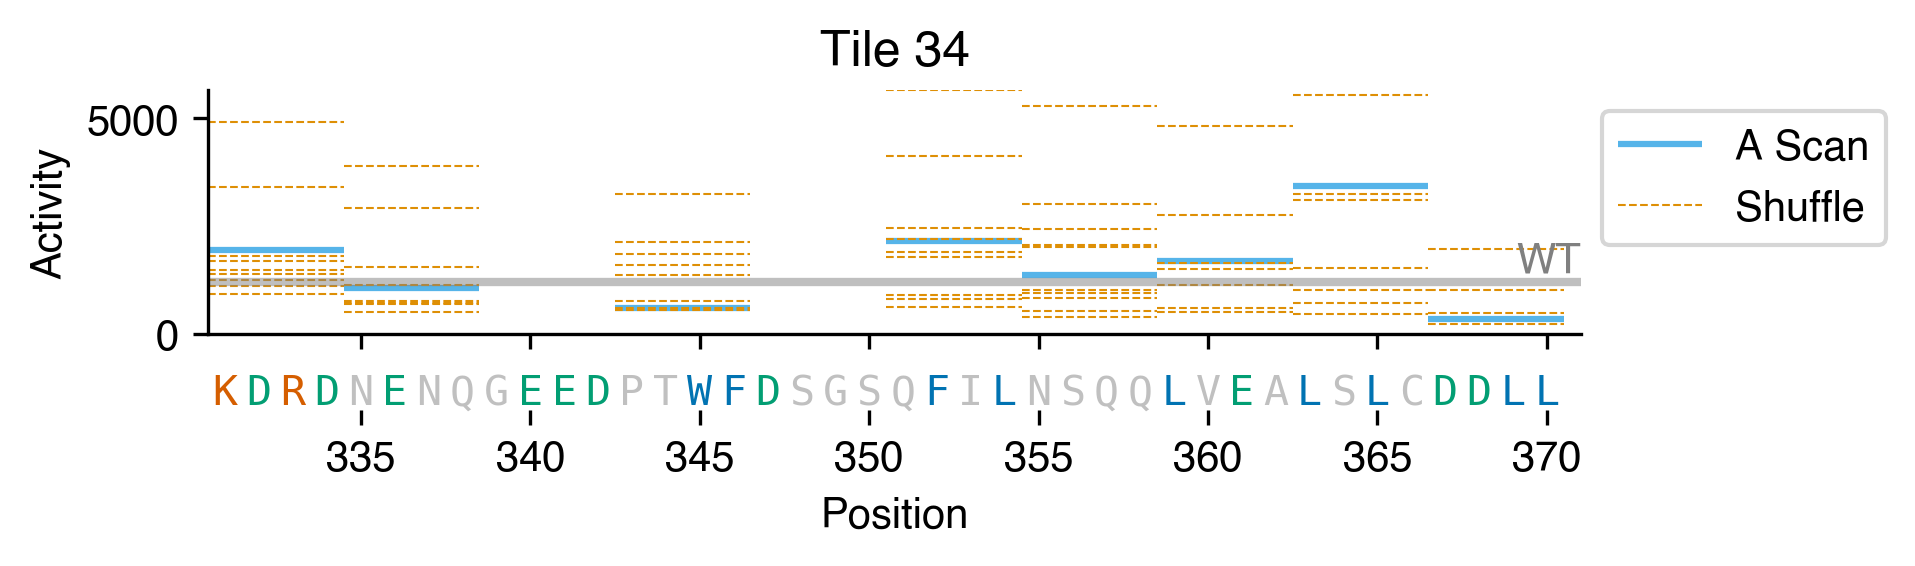

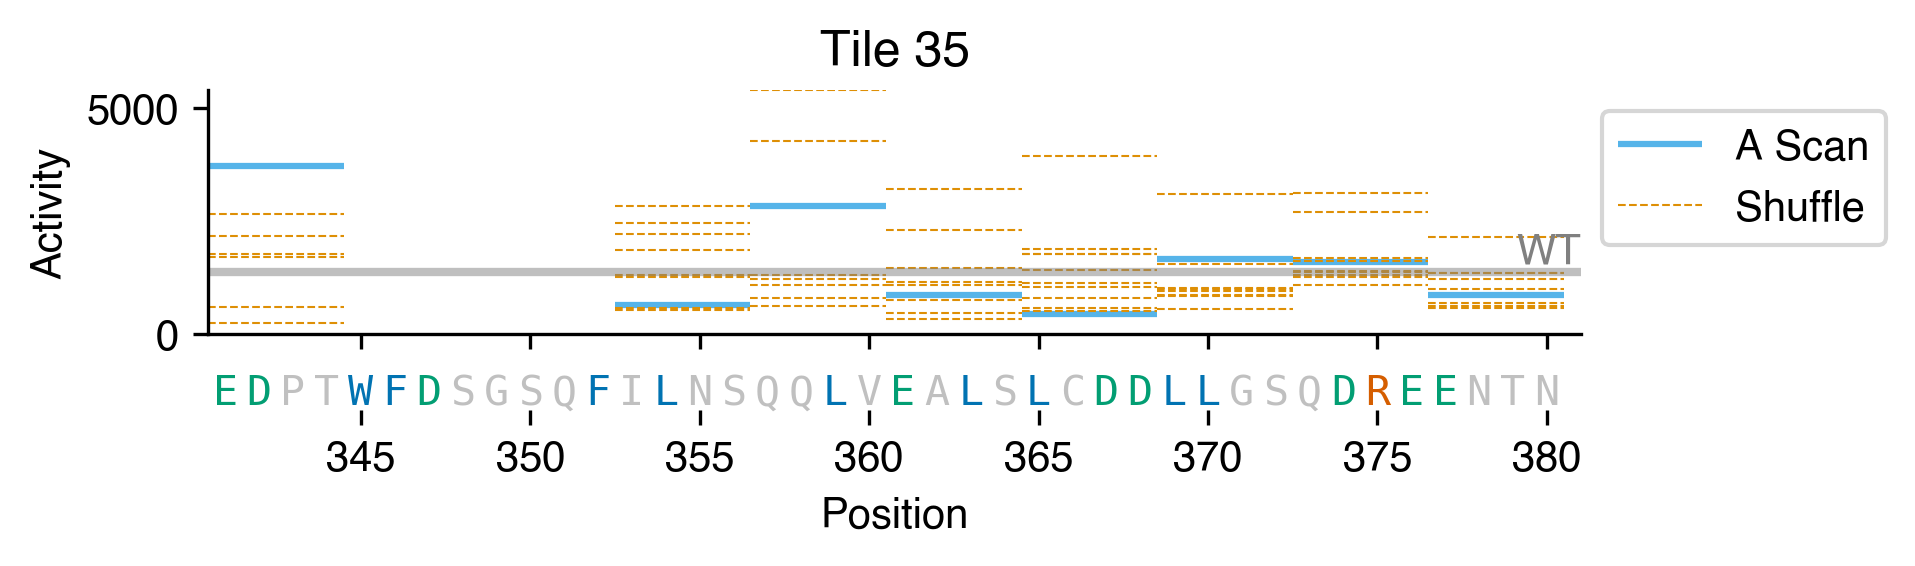

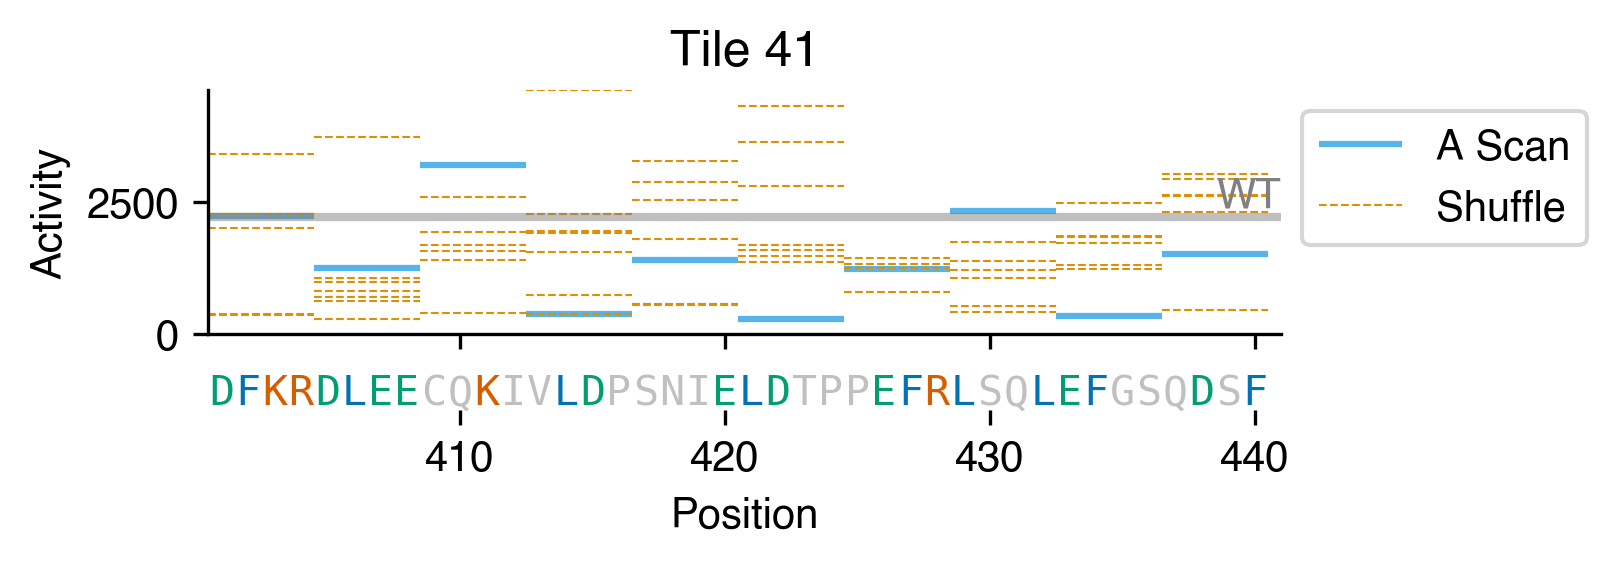

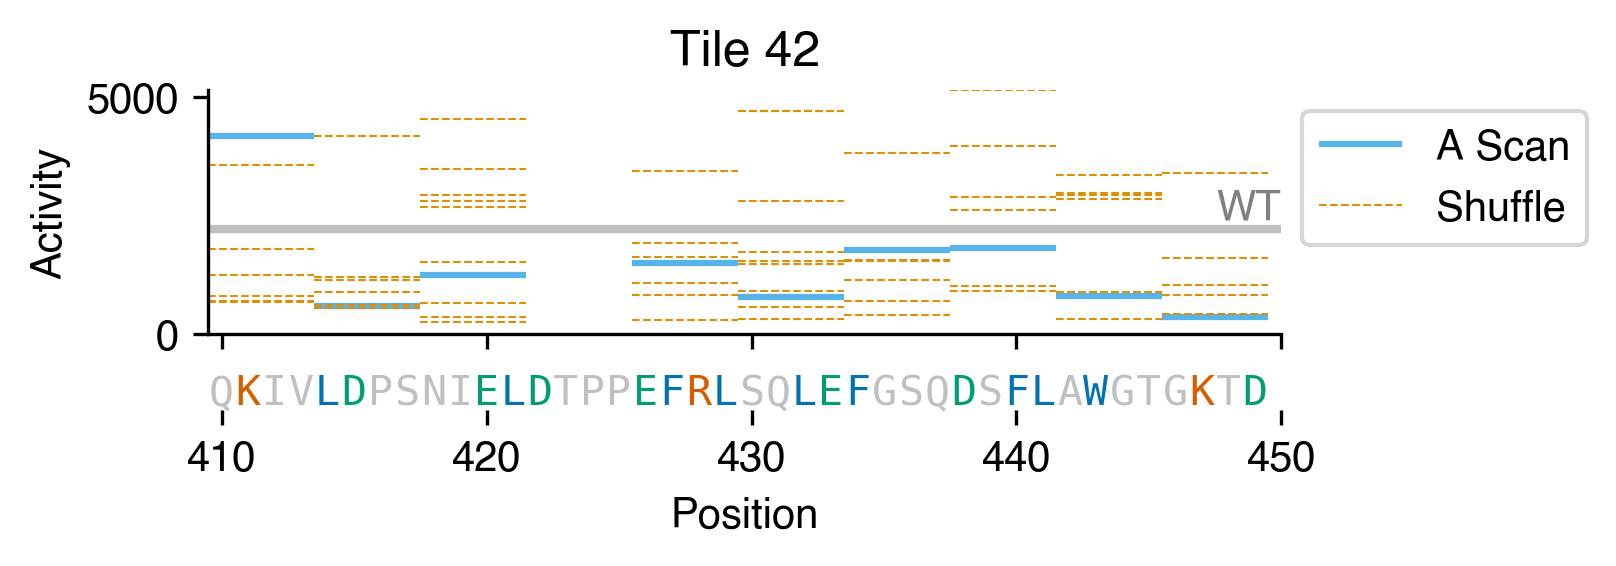

In [221]:
for tile_num in list(set(shuffle_vars_with_diff["tile"]) & set(Ascan_s_with_diff["tile_num"])):
    plot_tile_Ascan_and_shuffles(tile_num)
    #plt.savefig("../output/figures/shuffles_and_Ascan/" + str(tile_num) + ".png")

In [127]:
shuffle_Ascan_lined_up[shuffle_Ascan_lined_up["tile_num"] == 33][["var_start", "var_end_adj", "Activity_S3_1_var_A", "Activity_S3_1_var_shuffle"]]

,var_start,var_end_adj,Activity_S3_1_var_A,Activity_S3_1_var_shuffle
0,325,329,253.483884,NaN
1,325,329,253.483884,NaN
2,325,329,253.483884,NaN
3,325,329,253.483884,NaN
4,325,329,253.483884,NaN
5,325,329,253.483884,NaN
6,325,329,253.483884,541.754026
7,325,329,253.483884,1940.821638
8,325,329,253.483884,760.610922
9,325,329,253.483884,NaN
